In [1]:
import glob
import os

import pandas as pd
import numpy as np

import torch
from model import LightningWBoson
import train

from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm

import mplhep as hep
hep.style.use("ATLAS")

In [2]:
ckpt_files = glob.glob(f"./hww_pcres_regressor/logs/version_0/checkpoints/*")
print(f"Found checkpoint files: {ckpt_files}")
if not ckpt_files: 
    raise FileNotFoundError(f"No checkpoint files found in checkpoints")
ckpt_path = ckpt_files[0]  # Use the first checkpoint found
print(f"Using checkpoint: {ckpt_path}")

Found checkpoint files: ['./hww_pcres_regressor/logs/version_0/checkpoints/reg-epoch=258-val_loss=33.97.ckpt']
Using checkpoint: ./hww_pcres_regressor/logs/version_0/checkpoints/reg-epoch=258-val_loss=33.97.ckpt


In [3]:
dm = train.main(train=False) # Retrieve datamodule used in training
model = LightningWBoson.load_from_checkpoint(ckpt_path) # Load model from checkpoint
model.eval()

# Get the test dataloader
dm.setup(stage="test")
test_loader = dm.test_dataloader()

# Run inference
predictions = np.empty([0, dm.X.shape[1]-2]) # Without including W0 and W1 mass
true_labels = np.empty([0, dm.Y.shape[1]])
train_features = np.empty([0, dm.X.shape[1]])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

with torch.no_grad():
    for batch in test_loader:
        inputs, targets = batch
        inputs = inputs.to(device)
        targets = targets.to(device)
    
        outputs = model(inputs)
        
        train_features = np.append(train_features, inputs.cpu().numpy(), axis=0)
        predictions = np.append(predictions, outputs.cpu().numpy(), axis=0)
        true_labels = np.append(true_labels, targets.cpu().numpy(), axis=0)

Evaluation mode, loading checkpoints...
Training objects shape: (2963488, 10)
Target objects shape: (2963488, 10)
Loading model from checkpoint for evaluation... return datamodule


/opt/conda/envs/torch/lib/python3.11/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


Using test dataloader with 148174 samples.


In [4]:
true_lep0_px = train_features[:, 0]
true_lep0_py = train_features[:, 1]
true_lep0_pz = train_features[:, 2]
true_lep0_energy = train_features[:, 3]
true_lep1_px = train_features[:, 4]
true_lep1_py = train_features[:, 5]
true_lep1_pz = train_features[:, 6]
true_lep1_energy = train_features[:, 7]

In [5]:
pred_w0_px = predictions[..., 0]
pred_w0_py = predictions[..., 1]
pred_w0_pz = predictions[..., 2]
pred_w0_energy = predictions[..., 3]
pred_w1_px = predictions[..., 4]
pred_w1_py = predictions[..., 5]
pred_w1_pz = predictions[..., 6]
pred_w1_energy = predictions[..., 7]
pred_w0_mass_2 = pred_w0_energy**2 - (pred_w0_px**2 + pred_w0_py**2 + pred_w0_pz**2)
pred_w1_mass_2 = pred_w1_energy**2 - (pred_w1_px**2 + pred_w1_py**2 + pred_w1_pz**2)

true_w0_px = true_labels[..., 0]
true_w0_py = true_labels[..., 1]
true_w0_pz = true_labels[..., 2]
true_w0_energy = true_labels[..., 3]
true_w1_px = true_labels[..., 4]
true_w1_py = true_labels[..., 5]
true_w1_pz = true_labels[..., 6]
true_w1_energy = true_labels[..., 7]
true_w0_mass_2 = true_labels[..., 8] ** 2
true_w1_mass_2 = true_labels[..., 9] ** 2

In [6]:
def rmse(a, b):
    if  np.isnan(a).any() or np.isnan(b).any():
        print("Warning: NaN values detected in input arrays.")
    mask = ~np.isnan(a) & ~np.isnan(b)
    return np.sqrt(np.mean((a[mask] - b[mask]) ** 2))

In [7]:
def rel_err_func(a, b):
    if  np.isnan(a).any() or np.isnan(b).any():
        print("Warning: NaN values detected in input arrays.")
    if (np.any(b == 0)):
        print("Warning: Zero values detected in denominator array.")
    mask = ~np.isnan(a) & ~np.isnan(b) & (b != 0)
    return (a[mask] - b[mask]) / b[mask]

In [8]:
def err_bounds(x, rel_err=0.2, offset=5.0):
    delta = rel_err * np.abs(x) + offset
    upper = x + delta
    lower = x - delta
    return upper, lower

In [9]:
def plot_1d_hist(pred, truth, name, bins_edges=np.linspace(-200, 200, 101), unit="GeV", color="black", savepath=None):
    plt.hist(pred, bins=bins_edges, linewidth=2, color="red", histtype="step", label="Pred")
    plt.hist(truth, bins=bins_edges, linewidth=2, color="blue", histtype="step", label="True")
    plt.legend()
    plt.xlabel(unit, loc="right")
    plt.ylabel("Events", loc="top")
    plt.title(name, loc="right")
    
    txt = hep.atlas.label("Internal Simulation", data=True, loc=2, rlabel="")
    txt[0].set_color(color)
    txt[1].set_color(color)
    plt.tick_params(axis="both", which="major", pad=10)
    if savepath is not None:
        plt.savefig(savepath, bbox_inches="tight")
    plt.show()
def plot_2d_hist(pred, truth, name, bins_edges=np.linspace(-200, 200, 101), log=False, unit="GeV", color="black", vmax=1e3, offset=10.0, savepath=None):
    err = 0.2
    cor_mask = np.abs(rel_err_func(pred, truth)) <= err # set 20% relative error cut
    if log:
        norm = LogNorm(vmin=1, vmax=vmax)
        plt.hist2d(pred, truth, bins=[bins_edges, bins_edges], cmap="viridis", norm=norm)
    else:
        plt.hist2d(pred, truth, bins=[bins_edges, bins_edges], cmap="viridis", vmin=1, vmax=vmax)
        
    # Plot error guides aligned with bin edges
    upper, lower = err_bounds(bins_edges, rel_err=err, offset=offset)
    plt.plot(upper, bins_edges, color="gainsboro", linestyle="-", label=r"$\pm 20\% offset$")
    plt.plot(bins_edges, bins_edges, color="gainsboro", linestyle="--")
    plt.plot(lower, bins_edges, color="gainsboro", linestyle="-")
    
    plt.xlabel(f"Pred [{unit}]")
    plt.ylabel(f"True [{unit}]")
    plt.title(f"{name}"+f" with RMSE: {rmse(pred, truth):.2f}", loc="right")
    print(f"Rel err < 20%: {100*np.sum(cor_mask)/len(truth):.2f} %")
    
    txt = hep.atlas.label("Internal Simulation", data=True, loc=2, rlabel="")
    txt[0].set_color(color)
    txt[1].set_color(color)
    plt.tick_params(axis="both", which="major", pad=10) 
    plt.colorbar(label="Events")
    plt.gca().set_aspect("equal", adjustable="box")  # Make plot square
    if savepath is not None:
        plt.savefig(savepath, bbox_inches="tight")
    plt.show()
    # if log:
    #     plt.hist2d(pred[cor_mask], truth[cor_mask], bins=[bins_edges, bins_edges], cmap="viridis", norm=norm)
    # else:
    #     plt.hist2d(pred[cor_mask], truth[cor_mask], bins=[bins_edges, bins_edges], cmap="viridis", vmin=1, vmax=vmax)
    # # Plot error guides aligned with bin edges
    # upper, lower = err_bounds(bins_edges, rel_err=err)
    # plt.plot(upper, bins_edges, color="red", linestyle="-", label=r"$\pm 20\% offset$")
    # plt.plot(lower, bins_edges, color="red", linestyle="-")
    # plt.xlabel(f"Pred [{unit}]")
    # plt.ylabel(f"True [{unit}]")
    # plt.title(f"{name} (Rel err < 20%)"+f" with RMSE: {rmse(pred[cor_mask], truth[cor_mask]):.2f}", loc="right")
    # txt = hep.atlas.label("Internal Simulation", data=True, loc=2, rlabel="")
    # txt[0].set_color(color)
    # txt[1].set_color(color)
    # plt.tick_params(axis="both", which="major", pad=10) 
    # plt.colorbar(label="Events")
    # plt.gca().set_aspect("equal", adjustable="box")  # Make plot square
    # # if savepath is not None:
    # #     plt.savefig(savepath, bbox_inches="tight")
    # plt.show()

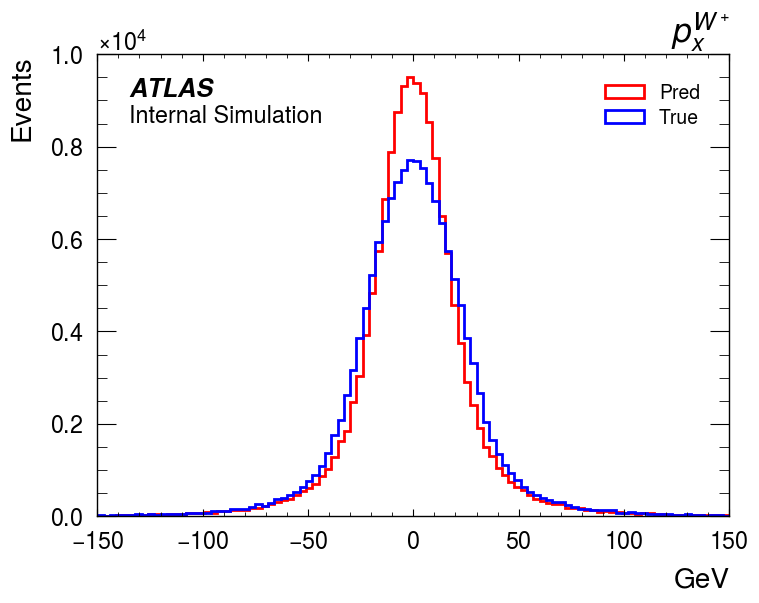

Rel err < 20%: 22.63 %


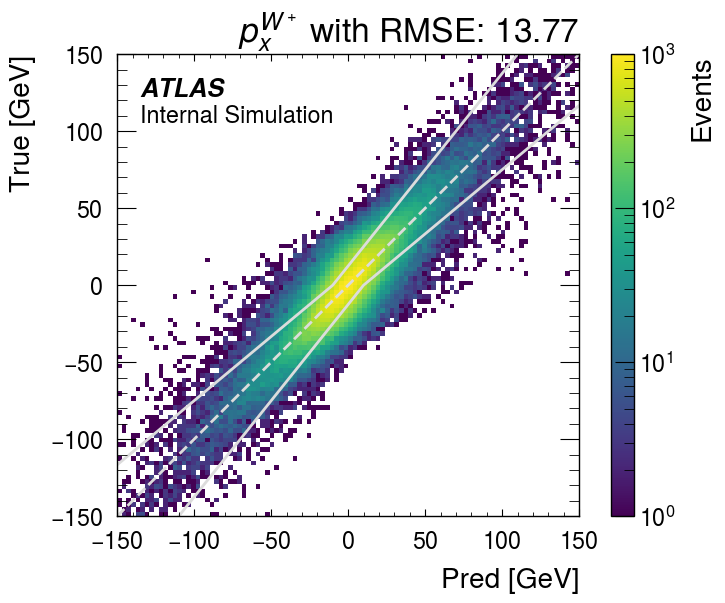

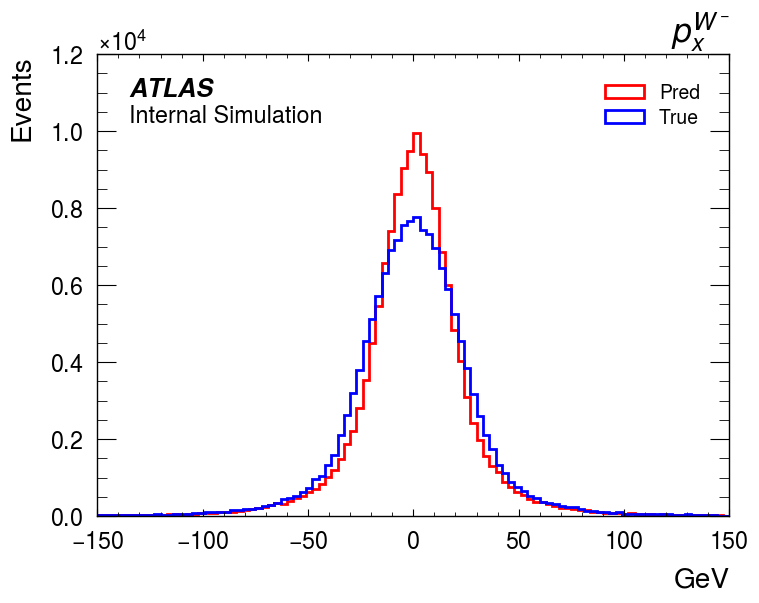

Rel err < 20%: 22.32 %


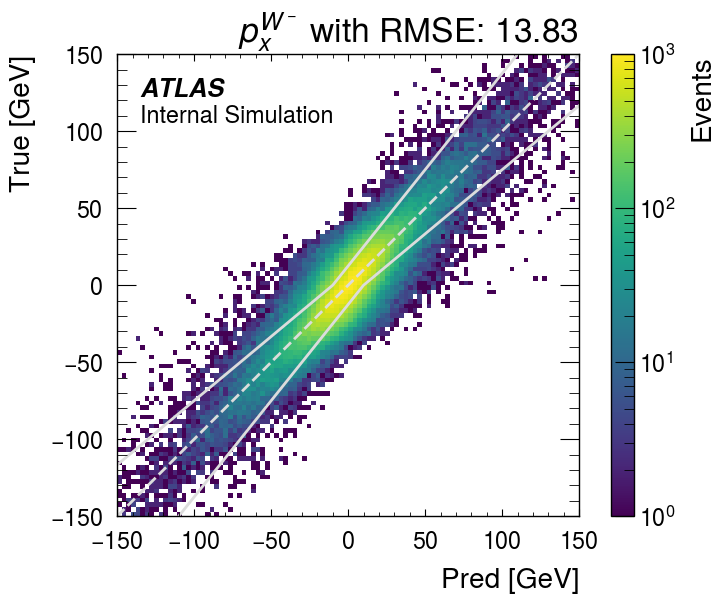

In [10]:
bins = np.linspace(-150, 150, 101)
plot_1d_hist(pred_w0_px, true_w0_px, bins_edges=bins, name=r"$p_x^{W^+}$", savepath="./figures/w_pos/px.pdf")
plot_2d_hist(pred_w0_px, true_w0_px, name=r"$p_x^{W^+}$", bins_edges=bins, log=True, savepath="./figures/w_pos/px_2d.pdf")
plot_1d_hist(pred_w1_px, true_w1_px, bins_edges=bins, name=r"$p_x^{W^-}$", savepath="./figures/w_neg/px.pdf")
plot_2d_hist(pred_w1_px, true_w1_px, name=r"$p_x^{W^-}$", bins_edges=bins, log=True, savepath="./figures/w_neg/px_2d.pdf")

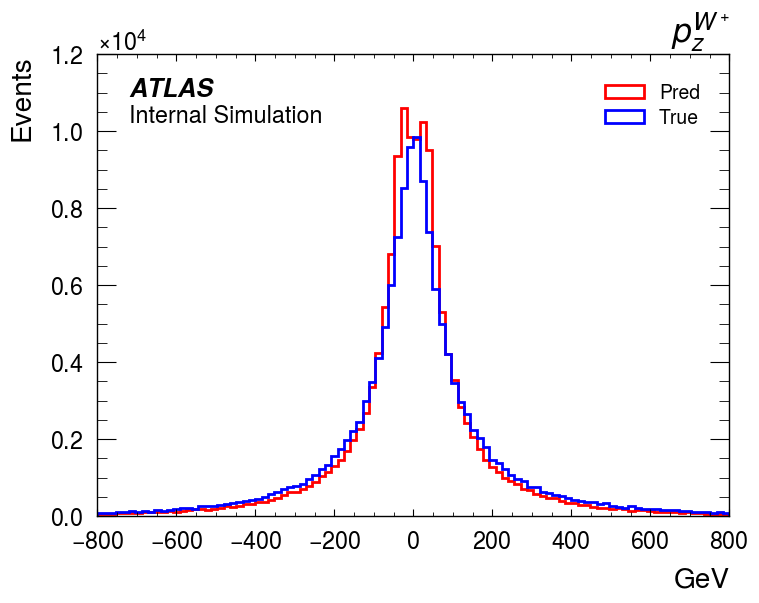

Rel err < 20%: 29.21 %


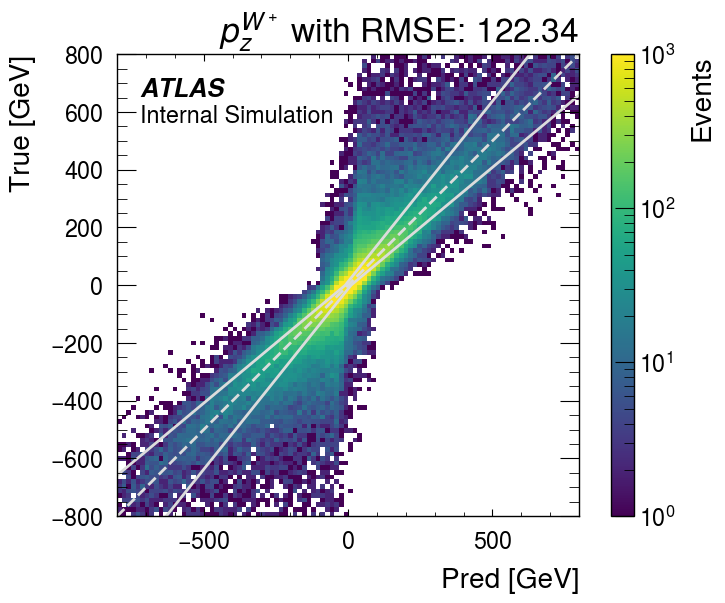

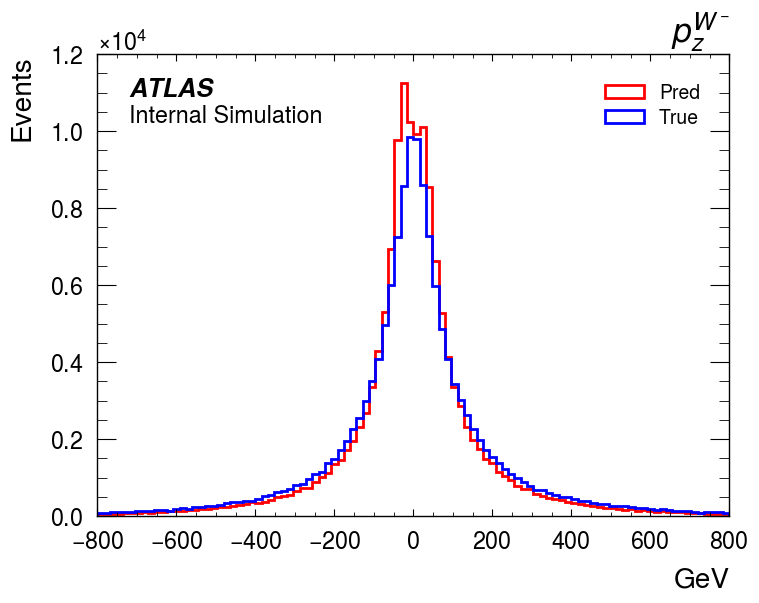

Rel err < 20%: 28.99 %


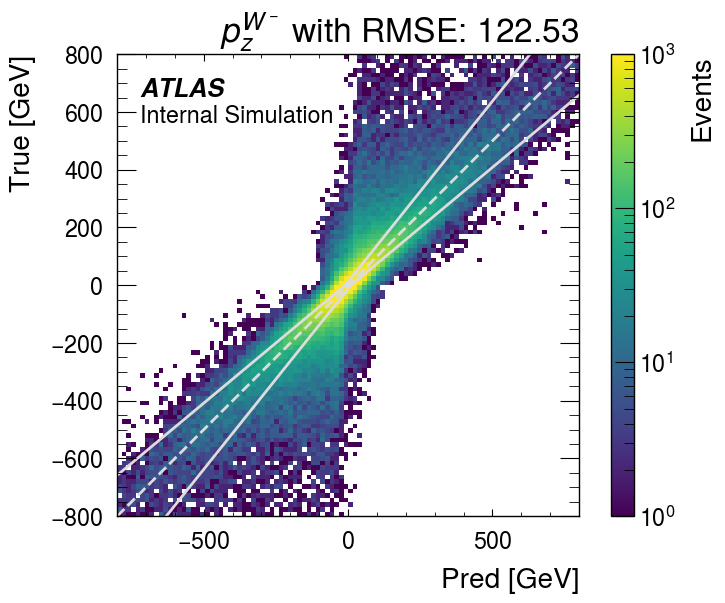

In [11]:
bins = np.linspace(-800, 800, 101)
plot_1d_hist(pred_w0_pz, true_w0_pz, bins_edges=bins, name=r"$p_z^{W^+}$", savepath="./figures/w_pos/pz.pdf")
plot_2d_hist(pred_w0_pz, true_w0_pz, name=r"$p_z^{W^+}$", bins_edges=bins, log=True, savepath="./figures/w_pos/pz_2d.pdf")
plot_1d_hist(pred_w1_pz, true_w1_pz, bins_edges=bins, name=r"$p_z^{W^-}$", savepath="./figures/w_neg/pz.pdf")
plot_2d_hist(pred_w1_pz, true_w1_pz, name=r"$p_z^{W^-}$", bins_edges=bins, log=True, savepath="./figures/w_neg/pz_2d.pdf")

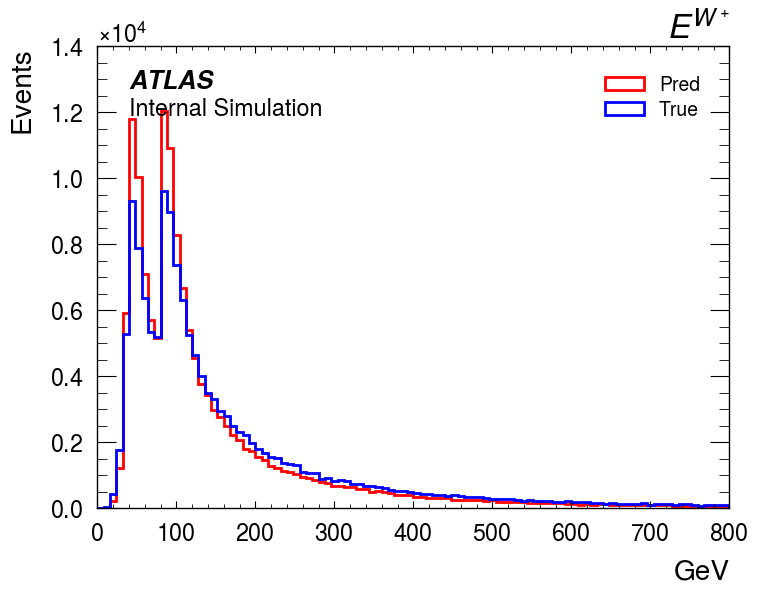

Rel err < 20%: 54.28 %


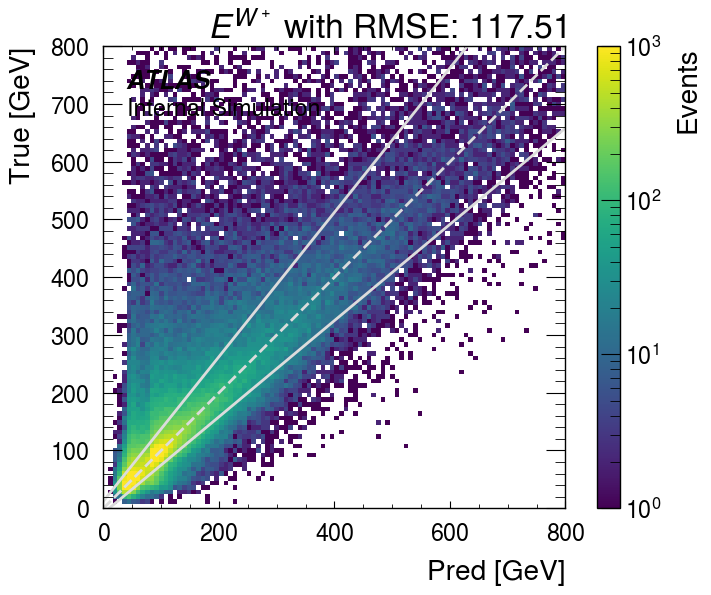

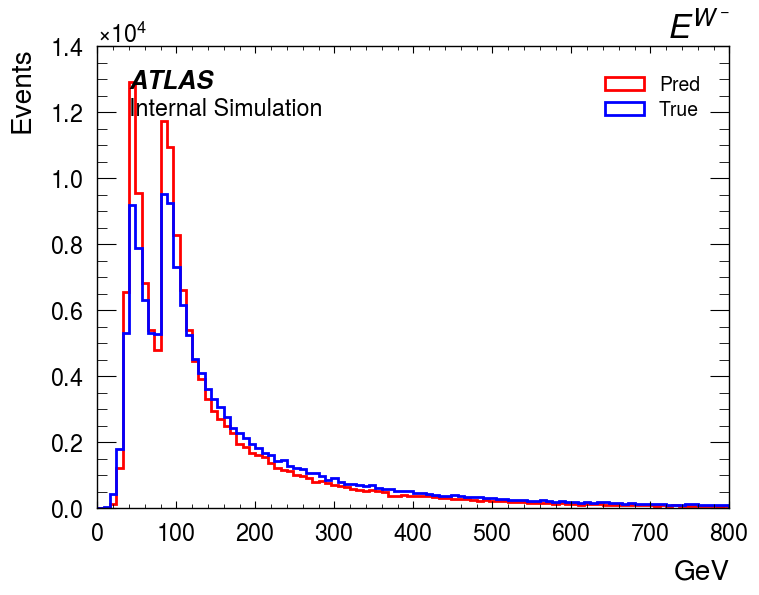

Rel err < 20%: 54.21 %


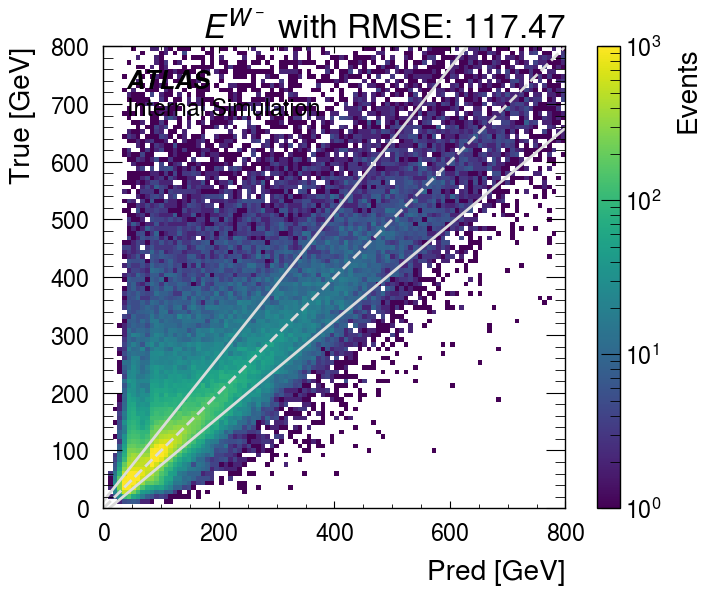

In [12]:
bins = np.linspace(0, 800, 101)
plot_1d_hist(pred_w0_energy, true_w0_energy, bins_edges=bins, name=r"$E^{W^+}$", savepath="./figures/w_pos/energy.pdf")
plot_2d_hist(pred_w0_energy, true_w0_energy, name=r"$E^{W^+}$", bins_edges=bins, log=True, color="black", savepath="./figures/w_pos/energy_2d.pdf")
plot_1d_hist(pred_w1_energy, true_w1_energy, bins_edges=bins, name=r"$E^{W^-}$", savepath="./figures/w_neg/energy.pdf")
plot_2d_hist(pred_w1_energy, true_w1_energy, name=r"$E^{W^-}$", bins_edges=bins, log=True, color="black", savepath="./figures/w_neg/energy_2d.pdf")

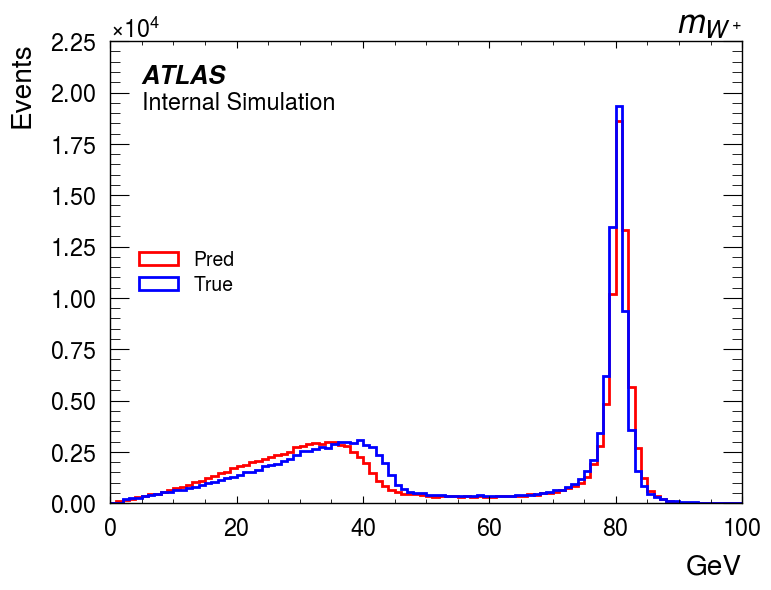

Rel err < 20%: 58.62 %


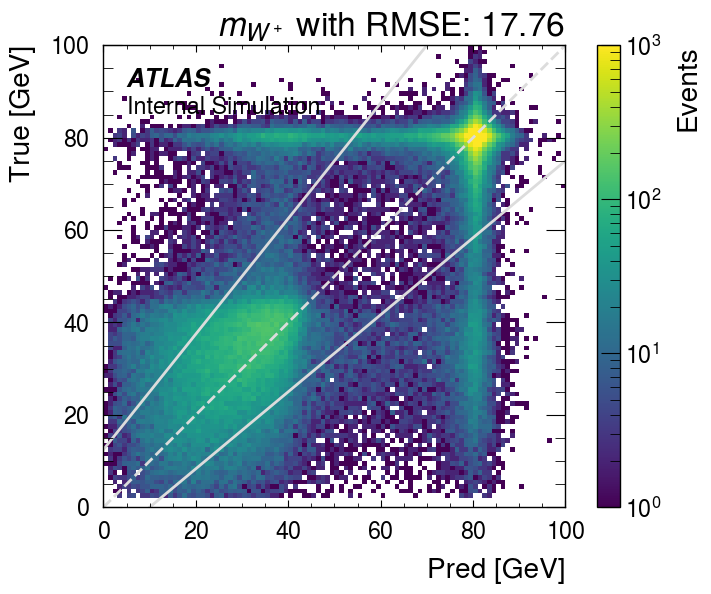

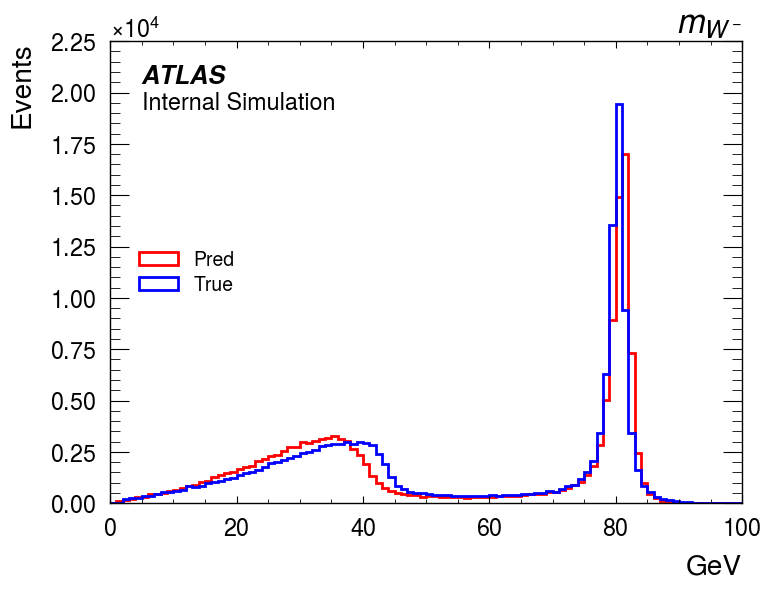

Rel err < 20%: 59.27 %


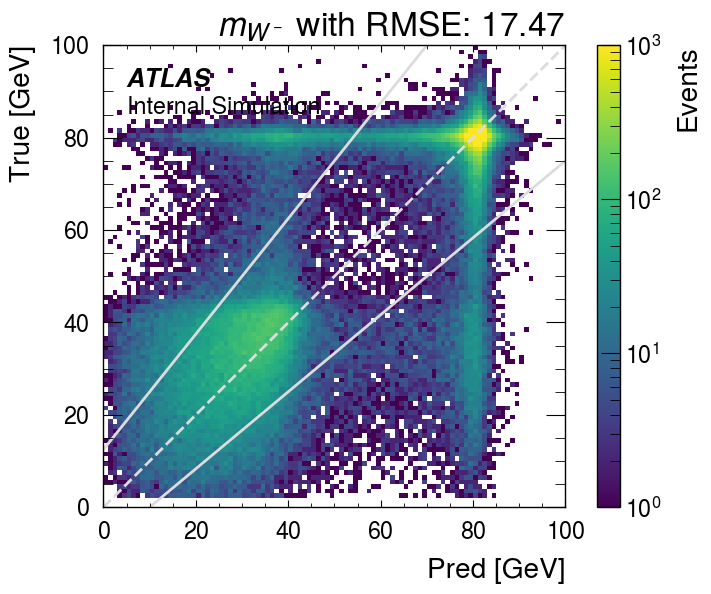

In [13]:
bins = np.linspace(0, 100, 101)
plot_1d_hist(np.sqrt(pred_w0_mass_2), np.sqrt(true_w0_mass_2), bins_edges=bins, name=r"$m_{W^+}$", unit="GeV", savepath="./figures/w_pos/mass.pdf")
plot_2d_hist(np.sqrt(pred_w0_mass_2), np.sqrt(true_w0_mass_2), name=r"$m_{W^+}$", bins_edges=bins, log=True, unit="GeV", savepath="./figures/w_pos/mass_2d.pdf")
plot_1d_hist(np.sqrt(pred_w1_mass_2), np.sqrt(true_w1_mass_2), bins_edges=bins, name=r"$m_{W^-}$", unit="GeV", savepath="./figures/w_neg/mass.pdf")
plot_2d_hist(np.sqrt(pred_w1_mass_2), np.sqrt(true_w1_mass_2), name=r"$m_{W^-}$", bins_edges=bins, log=True, unit="GeV", savepath="./figures/w_neg/mass_2d.pdf")

In [14]:
def plot_2d_res_hist(pred, truth, name_pos, name_neg, bins_edges=np.linspace(-200, 200, 101), log=False, unit="GeV", color="black", vmax=5e3, savepath=None):
    if log:
        norm = LogNorm(vmin=1, vmax=vmax)
        plt.hist2d(pred, truth, bins=[bins_edges, bins_edges], cmap="viridis", norm=norm)
    else:
        plt.hist2d(pred, truth, bins=[bins_edges, bins_edges], cmap="viridis", vmin=1, vmax=vmax)
    plt.xlabel(rf"$\text{{res}}$({name_pos}) [{unit}]")
    plt.ylabel(rf"$\text{{res}}$({name_neg}) [{unit}]")
    # plt.title(rf"{title}", loc="right")
    txt = hep.atlas.label("Internal Simulation", data=True, loc=0, rlabel="")
    txt[0].set_color(color)
    txt[1].set_color(color)
    plt.tick_params(axis="both", which="major", pad=10) 
    plt.colorbar(label="Events")
    plt.gca().set_aspect("equal", adjustable="box")  # Make plot square
    if savepath is not None:
        plt.savefig(savepath, bbox_inches="tight")
    plt.show()

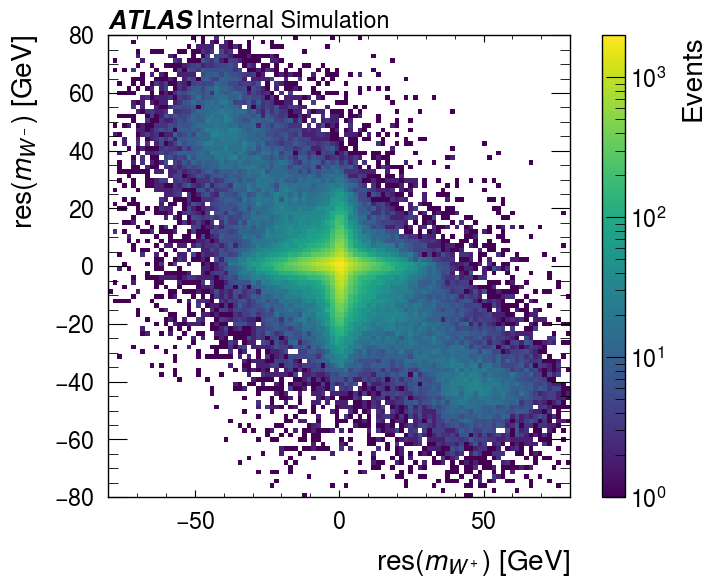

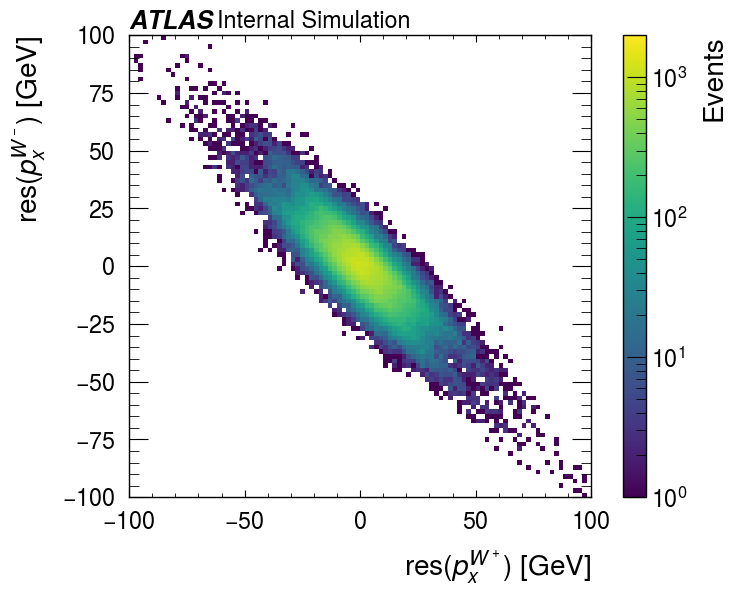

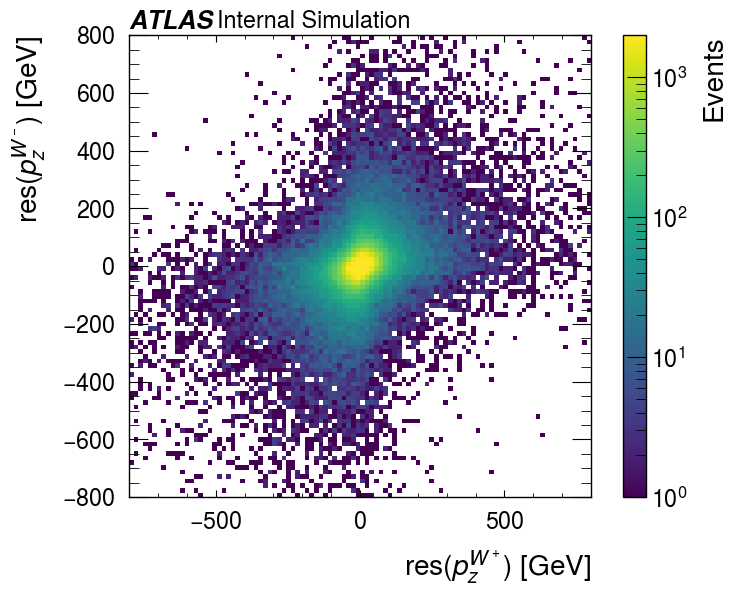

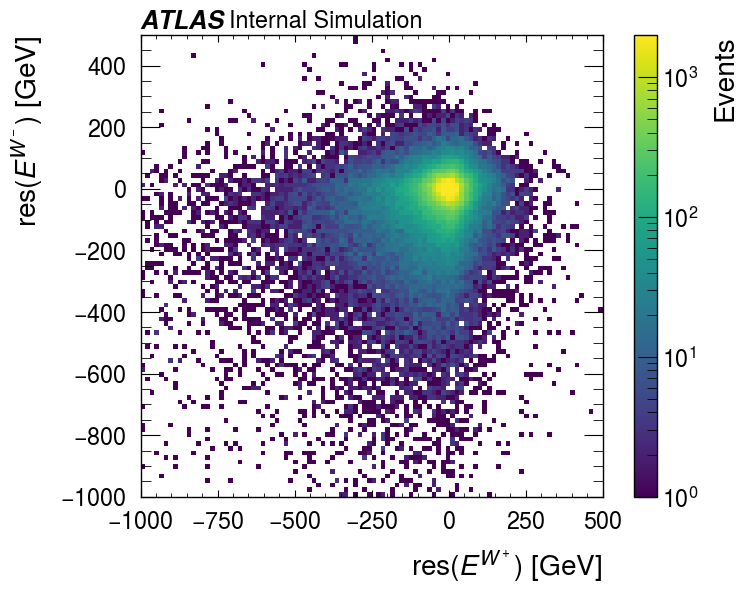

In [15]:
w0_mass_res = np.sqrt(pred_w0_mass_2) - np.sqrt(true_w0_mass_2)
w1_res = np.sqrt(pred_w1_mass_2) - np.sqrt(true_w1_mass_2)
plot_2d_res_hist(w0_mass_res, w1_res, name_pos=r"$m_{W^+}$", name_neg=r"$m_{W^-}$", bins_edges=np.linspace(-80, 80, 101), log=True, unit="GeV", color="black", vmax=2e3, savepath="./figures/mass_res_2d.pdf")

w0_px_res = pred_w0_px - true_w0_px
w1_px_res = pred_w1_px - true_w1_px
plot_2d_res_hist(w0_px_res, w1_px_res, name_pos=r"$p_x^{W^+}$", name_neg=r"$p_x^{W^-}$", bins_edges=np.linspace(-100, 100, 101), log=True, unit="GeV", color="black", vmax=2e3, savepath="./figures/px_res_2d.pdf")

w0_pz_res = pred_w0_pz - true_w0_pz
w1_pz_res = pred_w1_pz - true_w1_pz
plot_2d_res_hist(w0_pz_res, w1_pz_res, name_pos=r"$p_z^{W^+}$", name_neg=r"$p_z^{W^-}$", bins_edges=np.linspace(-800, 800, 101), log=True, unit="GeV", color="black", vmax=2e3, savepath="./figures/pz_res_2d.pdf")	

w0_energy_res = pred_w0_energy - true_w0_energy
w1_energy_res = pred_w1_energy - true_w1_energy
plot_2d_res_hist(w0_energy_res, w1_energy_res, name_pos=r"$E^{W^+}$", name_neg=r"$E^{W^-}$", bins_edges=np.linspace(-1000, 500, 101), log=True, unit="GeV", color="black", vmax=2e3, savepath="./figures/energy_res_2d.pdf")

In [16]:
from ohbboosting import Booster

true_w0_p4 = np.stack([true_w0_px, true_w0_py, true_w0_pz, true_w0_energy], axis=1)
true_l0_p4 = np.stack([true_lep0_px,true_lep0_py,true_lep0_pz,true_lep0_energy], axis=1)
true_w1_p4 = np.stack([true_w1_px, true_w1_py, true_w1_pz, true_w1_energy], axis=1)
true_l1_p4 = np.stack([true_lep1_px,true_lep1_py,true_lep1_pz,true_lep1_energy], axis=1)

particles = np.concatenate(
	[
		true_w0_p4,
		true_l0_p4,
		true_w1_p4,
		true_l1_p4,
	],
	axis=-1,
)
booster = Booster(particles)
booster.setup()
print(particles.shape)
true_l0_theta_phi, true_l1_theta_phi = booster.lep_theta_phi_in_w_rest()
# true_xi_pos, true_xi_neg = booster.lep_xi_in_w_rest()
# true_cglmp_bij = booster.cglmp_bij()

Make sure the input particles are ordered as [W+, l+, W-, l-]!
Booster setup completed.
(148174, 16)


In [17]:
pred_w0_p4 = np.stack([pred_w0_px, pred_w0_py, pred_w0_pz, pred_w0_energy], axis=1)
pred_w1_p4 = np.stack([pred_w1_px, pred_w1_py, pred_w1_pz, pred_w1_energy], axis=1)

particles = np.concatenate(
	[
		pred_w0_p4,
		true_l0_p4, # we can measure lepton 4-momentum precisely
		pred_w1_p4,
		true_l1_p4,
	],
	axis=-1,
)
booster = Booster(particles)
booster.setup()
print(particles.shape)
pred_l0_theta_phi, pred_l1_theta_phi = booster.lep_theta_phi_in_w_rest()
# pred_xi_pos, pred_xi_neg = booster.lep_xi_in_w_rest()
# pred_cglmp_bij = booster.cglmp_bij()

Make sure the input particles are ordered as [W+, l+, W-, l-]!


Booster setup completed.
(148174, 16)


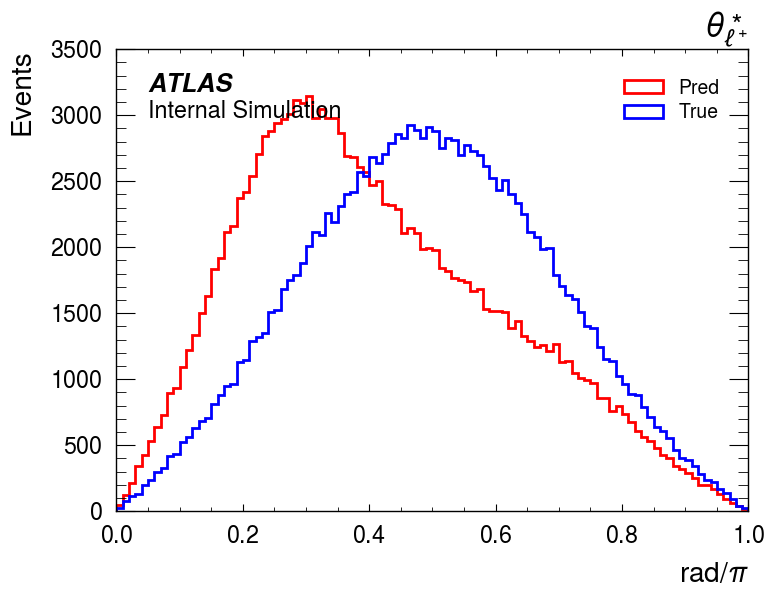

l+ theta RMSE: 0.21882291675686955
Rel err < 20%: 34.84 %


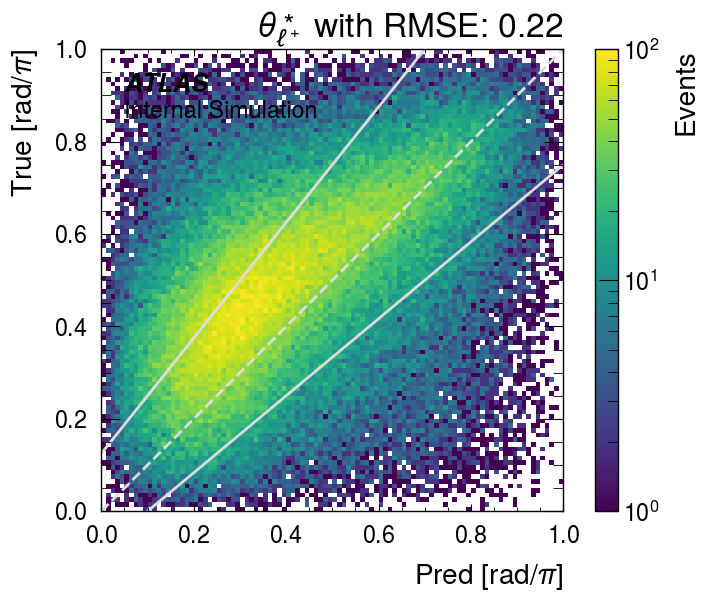

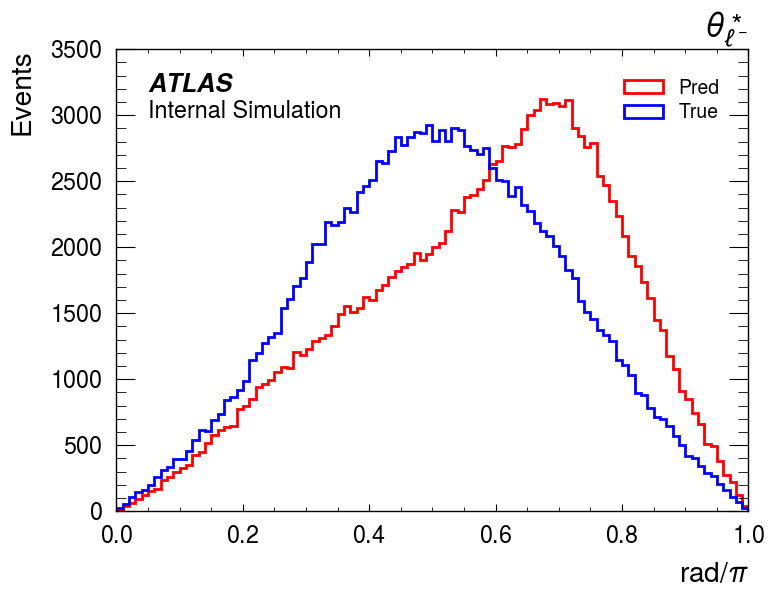

l_ theta RMSE: 0.2149634355300327
Rel err < 20%: 40.38 %


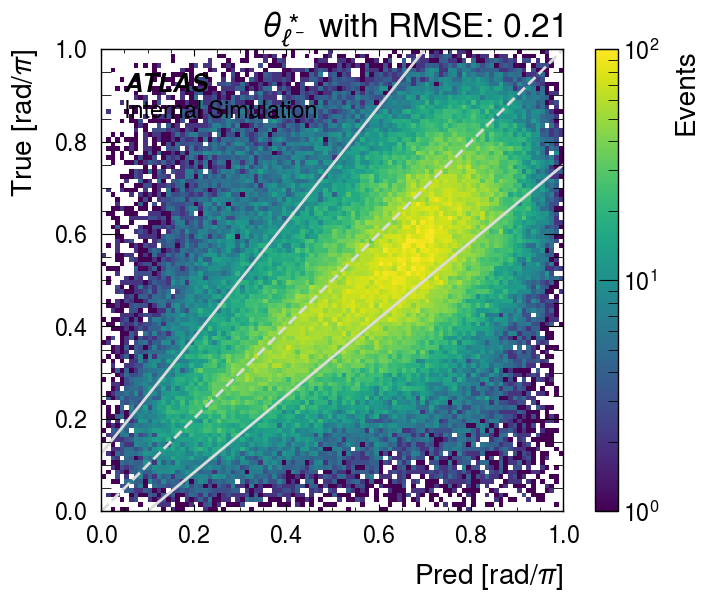

In [18]:
plot_1d_hist(pred_l0_theta_phi[0], true_l0_theta_phi[0], r"$\theta^\ast_{\ell^+}$", np.linspace(0, 1, 101), unit="rad/$\pi$", savepath="./figures/lep_pos/theta.pdf")
print("l+ theta RMSE:", rmse(pred_l0_theta_phi[0], true_l0_theta_phi[0]))
plot_2d_hist(pred_l0_theta_phi[0], true_l0_theta_phi[0], r"$\theta^\ast_{\ell^+}$", np.linspace(0, 1, 101), log=True, unit="rad/$\pi$", color="black", vmax=1e2, savepath="./figures/lep_pos/theta_2d.pdf", offset=0.1)
plot_1d_hist(pred_l1_theta_phi[0], true_l1_theta_phi[0], r"$\theta^\ast_{\ell^-}$", np.linspace(0, 1, 101), unit="rad/$\pi$", savepath="./figures/lep_neg/theta.pdf")
print("l_ theta RMSE:", rmse(pred_l1_theta_phi[0], true_l1_theta_phi[0]))
plot_2d_hist(pred_l1_theta_phi[0], true_l1_theta_phi[0], r"$\theta^\ast_{\ell^-}$", np.linspace(0, 1, 101), log=True, unit="rad/$\pi$", color="black", vmax=1e2, savepath="./figures/lep_neg/theta_2d.pdf", offset=0.1)

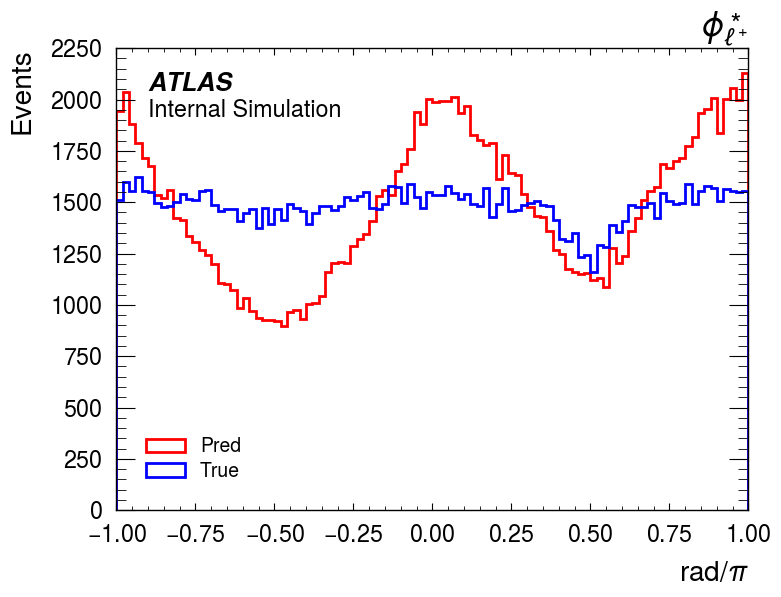

l+ phi RMSE: 0.7316692593763803
Rel err < 20%: 21.30 %


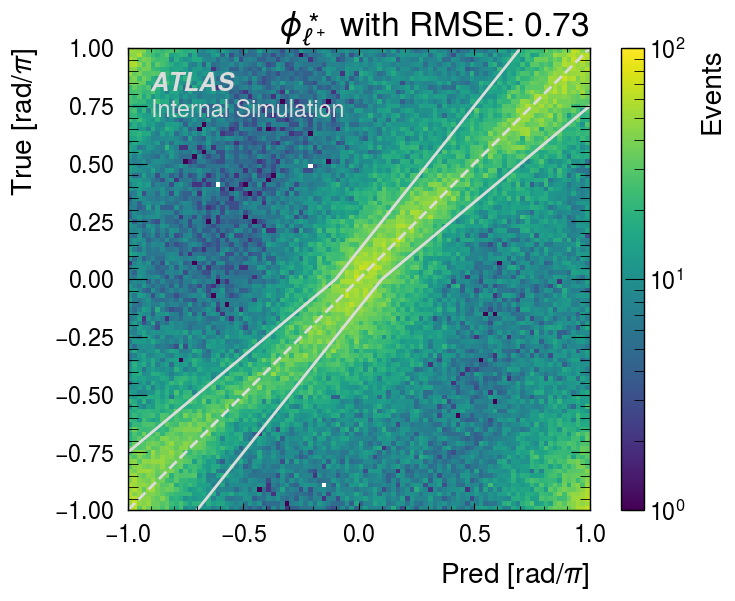

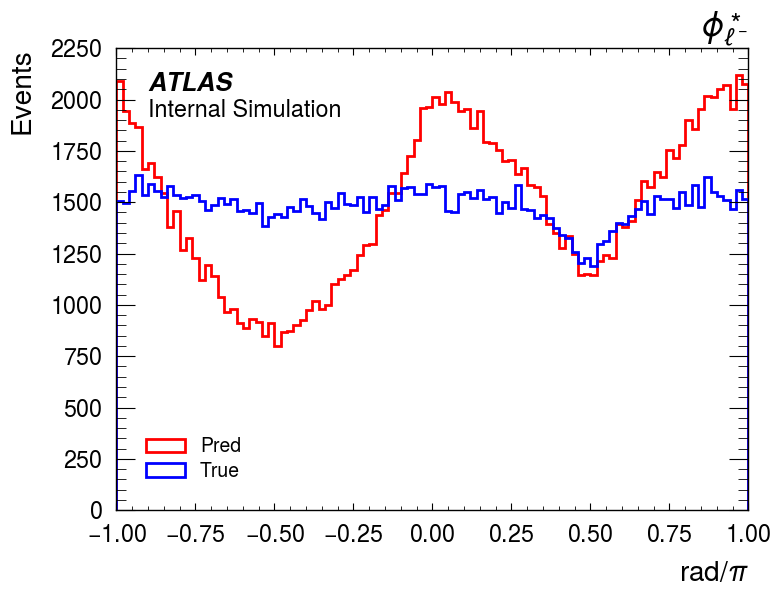

l- phi RMSE: 0.7265333907675288
Rel err < 20%: 21.47 %


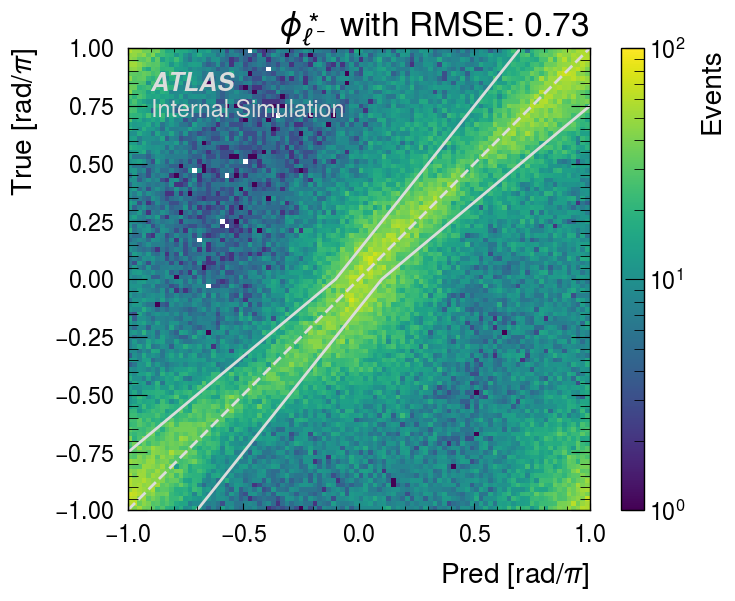

In [19]:
plot_1d_hist(pred_l0_theta_phi[1], true_l0_theta_phi[1], r"$\phi^\ast_{\ell^+}$", np.linspace(-1, 1, 101), unit="rad/$\pi$", savepath="./figures/lep_pos/phi.pdf")
print("l+ phi RMSE:", rmse(pred_l0_theta_phi[1], true_l0_theta_phi[1]))
plot_2d_hist(pred_l0_theta_phi[1], true_l0_theta_phi[1], r"$\phi^\ast_{\ell^+}$", np.linspace(-1, 1, 101), log=True, unit="rad/$\pi$", color="gainsboro", vmax=1e2, savepath="./figures/lep_pos/phi_2d.pdf", offset=0.1)
plot_1d_hist(pred_l1_theta_phi[1], true_l1_theta_phi[1], r"$\phi^\ast_{\ell^-}$", np.linspace(-1, 1, 101), unit="rad/$\pi$", savepath="./figures/lep_neg/phi.pdf")
print("l- phi RMSE:", rmse(pred_l1_theta_phi[1], true_l1_theta_phi[1]))
plot_2d_hist(pred_l1_theta_phi[1], true_l1_theta_phi[1], r"$\phi^\ast_{\ell^-}$", np.linspace(-1, 1, 101), log=True, unit="rad/$\pi$", color="gainsboro", vmax=1e2, savepath="./figures/lep_neg/phi_2d.pdf", offset=0.1)

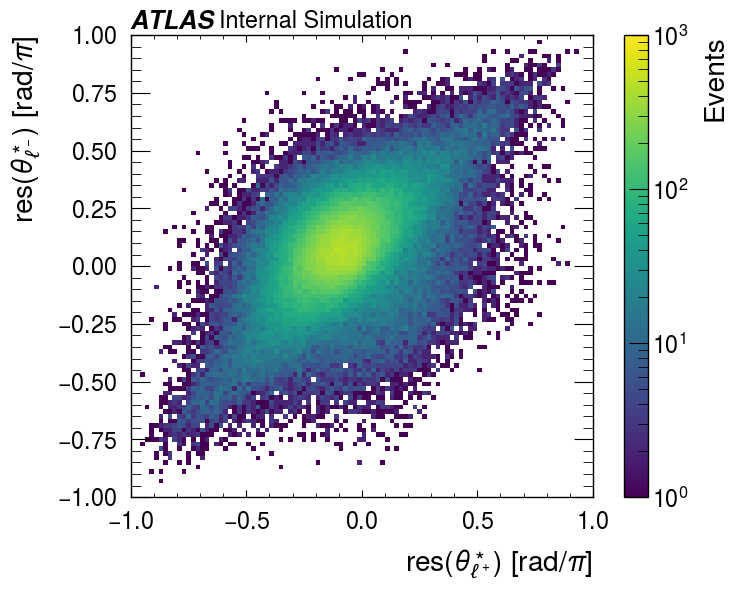

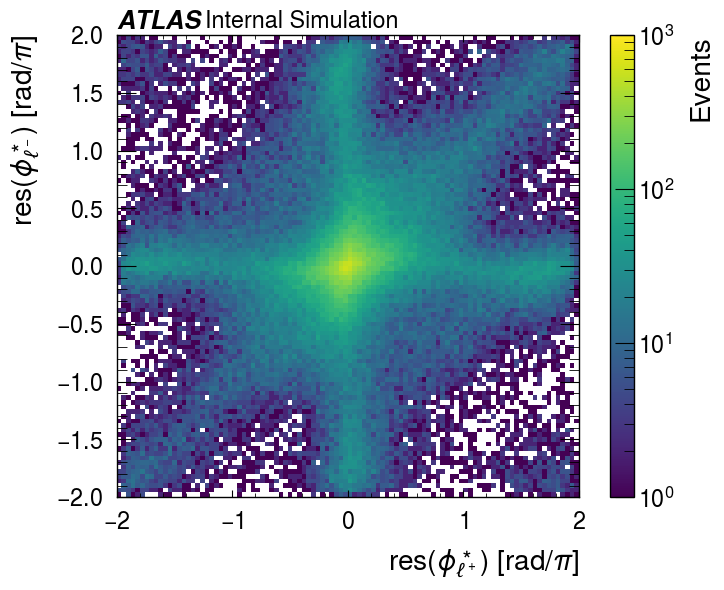

In [20]:
l0_theta_res = pred_l0_theta_phi[0] - true_l0_theta_phi[0]
l1_theta_res = pred_l1_theta_phi[0] - true_l1_theta_phi[0]
plot_2d_res_hist(l0_theta_res, l1_theta_res, name_pos=r"$\theta^\ast_{\ell^+}$", name_neg=r"$\theta^\ast_{\ell^-}$", bins_edges=np.linspace(-1, 1, 101), log=True, unit="rad/$\pi$", color="black", vmax=1e3, savepath="./figures/lep_theta_res_2d.pdf")

l0_phi_res = pred_l0_theta_phi[1] - true_l0_theta_phi[1]
l1_phi_res = pred_l1_theta_phi[1] - true_l1_theta_phi[1]
plot_2d_res_hist(l0_phi_res, l1_phi_res, name_pos=r"$\phi^\ast_{\ell^+}$", name_neg=r"$\phi^\ast_{\ell^-}$", bins_edges=np.linspace(-2, 2, 101), log=True, unit="rad/$\pi$", color="black", vmax=1e3, savepath="./figures/lep_phi_res_2d.pdf")

In [21]:
def dphi(phi1, phi2):
    phi_diff = phi1 * np.pi - phi2 * np.pi
    phi_diff = np.where(phi_diff < 0.0, -phi_diff, phi_diff)
    phi_diff = np.where(phi_diff > 2.0 * np.pi, phi_diff - 2.0 * np.pi, phi_diff)
    phi_diff = np.where(phi_diff >= np.pi, 2.0 * np.pi - phi_diff, phi_diff)
    return np.divide(phi_diff, np.pi)

def dtheta(theta1, theta2):
	theta_diff = theta1 * np.pi - theta2 * np.pi
	theta_diff = np.where(theta_diff < 0.0, -theta_diff, theta_diff)
	theta_diff = np.where(theta_diff > np.pi, theta_diff - np.pi, theta_diff)
	return np.divide(theta_diff, np.pi)

In [22]:
def plot_1d_true_pred_diff(diff, name, bins_edges=np.linspace(-1, 1, 101), unit="rad/$\pi$", color="black", savepath=None):
	plt.hist(diff, bins=bins_edges, linewidth=2, color="green", histtype="step", label=name)
	plt.legend()
	plt.xlabel(f"{name} [{unit}]", loc="right")
	plt.ylabel("Events", loc="top")
	# plt.title(name, loc="right")
	
	txt = hep.atlas.label("Internal Simulation", data=True, loc=2, rlabel="")
	txt[0].set_color(color)
	txt[1].set_color(color)
	plt.tick_params(axis="both", which="major", pad=10)
	if savepath is not None:
		plt.savefig(savepath, bbox_inches="tight")
	plt.show()

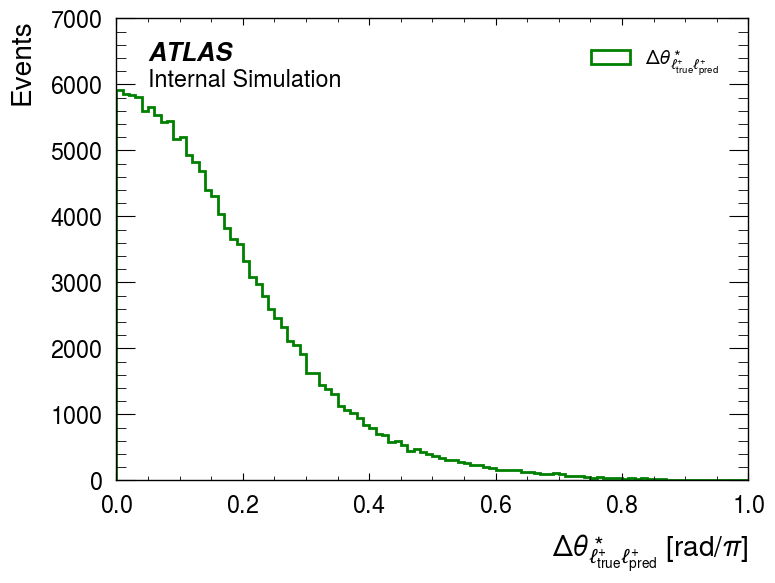

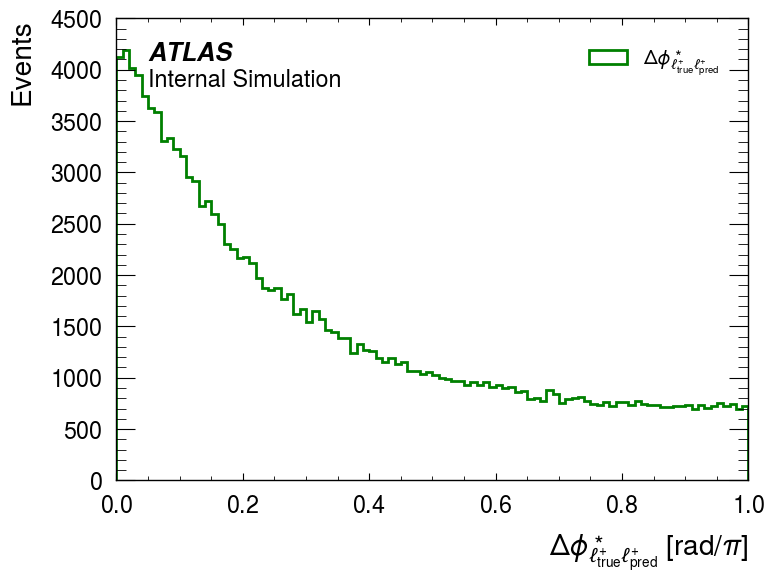

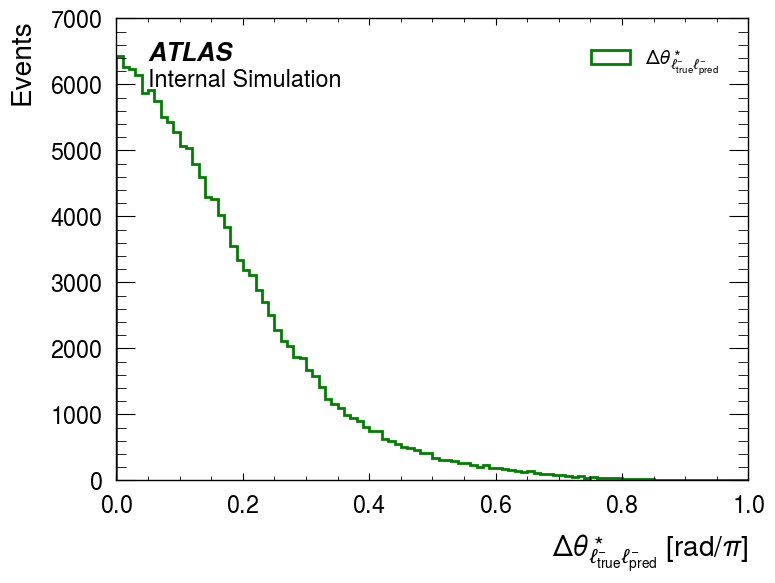

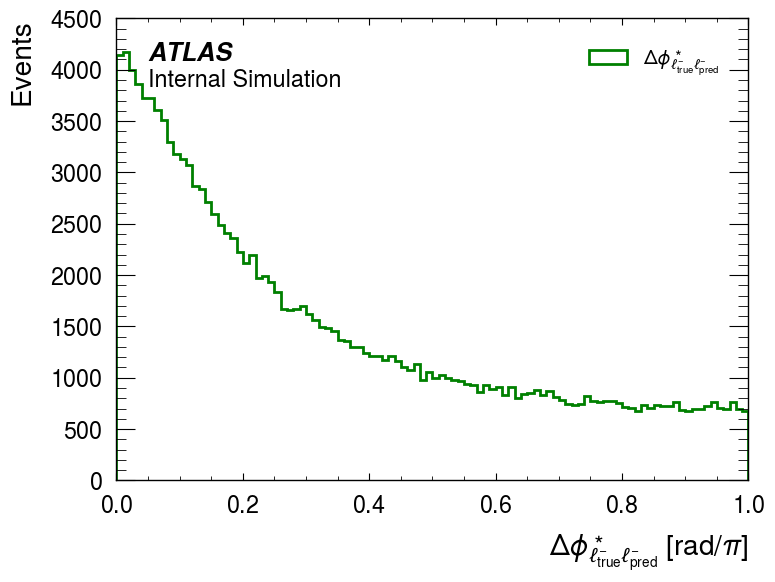

In [23]:
dtheta_pos = dtheta(pred_l0_theta_phi[0], true_l0_theta_phi[0])
dphi_pos = dphi(pred_l0_theta_phi[1], true_l0_theta_phi[1])
dtheta_neg = dtheta(pred_l1_theta_phi[0], true_l1_theta_phi[0])
dphi_neg = dphi(pred_l1_theta_phi[1], true_l1_theta_phi[1])

plot_1d_true_pred_diff(dtheta_pos, r"$\Delta \theta_{\ell^{+}_\text{true}\ell^{+}_\text{pred}}^\ast$", np.linspace(0, 1, 101), unit="rad/$\pi$", savepath="./figures/dilep/delta_theta_pos_diff.pdf")
plot_1d_true_pred_diff(dphi_pos, r"$\Delta \phi_{\ell^{+}_\text{true}\ell^{+}_\text{pred}}^\ast$", np.linspace(0, 1, 101), unit="rad/$\pi$", savepath="./figures/dilep/delta_phi_pos_diff.pdf")
plot_1d_true_pred_diff(dtheta_neg, r"$\Delta \theta_{\ell^{-}_\text{true}\ell^{-}_\text{pred}}^\ast$", np.linspace(0, 1, 101), unit="rad/$\pi$", savepath="./figures/dilep/delta_theta_neg_diff.pdf")
plot_1d_true_pred_diff(dphi_neg, r"$\Delta \phi_{\ell^{-}_\text{true}\ell^{-}_\text{pred}}^\ast$", np.linspace(0, 1, 101), unit="rad/$\pi$", savepath="./figures/dilep/delta_phi_neg_diff.pdf")

In [24]:
# plot_1d_hist(dtheta(pred_l0_theta_phi[0], pred_l1_theta_phi[0]), dtheta(true_l0_theta_phi[0], true_l1_theta_phi[0]), r"$\Delta \theta_{\ell\ell}^\ast$", np.linspace(0, 0.8, 101), unit="rad/$\pi$", savepath="./figures/dilep/delta_theta.pdf")
# plot_2d_hist(dtheta(pred_l0_theta_phi[0], pred_l1_theta_phi[0]), dtheta(true_l0_theta_phi[0], true_l1_theta_phi[0]), r"$\Delta \theta_{\ell\ell}^\ast$", np.linspace(0, 0.8, 101), log=True, unit="rad/$\pi$", vmax=2e3, savepath="./figures/dilep/delta_theta_2d.pdf")
# plot_1d_hist(dphi(pred_l0_theta_phi[1], pred_l1_theta_phi[1]), dphi(true_l0_theta_phi[1], true_l1_theta_phi[1]), r"$\Delta \phi_{\ell\ell}^\ast$", np.linspace(0, 1, 101), unit="rad/$\pi$", savepath="./figures/dilep/delta_phi.pdf")
# plot_2d_hist(dphi(pred_l0_theta_phi[1], pred_l1_theta_phi[1]), dphi(true_l0_theta_phi[1], true_l1_theta_phi[1]), r"$\Delta \phi_{\ell\ell}^\ast$", np.linspace(0, 1, 101), log=True, unit="rad/$\pi$", color="gainsboro", vmax=2e3, savepath="./figures/dilep/delta_phi_2d.pdf")

In [25]:
def plot_1d_swap_hist(pred, truth, pred_swap, true_swap, name, bins_edges=np.linspace(-200, 200, 101), unit="GeV", color="black", savepath=None):
    plt.hist(pred, bins=bins_edges, linewidth=2, color="red", histtype="step", label="Pred")
    plt.hist(truth, bins=bins_edges, linewidth=2, color="blue", histtype="step", label="True")
    plt.hist(pred_swap, bins=bins_edges, linewidth=2, color="tab:orange", histtype="step", label="Pred (tagged)")
    plt.hist(true_swap, bins=bins_edges, linewidth=2, color="tab:blue", histtype="step", label="True (tagged)")
    plt.semilogy()
    plt.legend()
    plt.xlabel(unit, loc="right")
    plt.ylabel("Events", loc="top")
    plt.title(name, loc="right")

    txt = hep.atlas.label("Internal Simulation", data=True, loc=2, rlabel="")
    txt[0].set_color(color)
    txt[1].set_color(color)
    plt.tick_params(axis="both", which="major", pad=10)
    if savepath is not None:
        plt.savefig(savepath, bbox_inches="tight")
    plt.show()

def plot_2d_swap_hist(pred, truth, name, bins_edges=np.linspace(-200, 200, 101), log=False, unit="GeV", color="black", vmax=5e3, offset=5.0, savepath=None):
    if log:
        norm = LogNorm(vmin=1, vmax=vmax)
        plt.hist2d(pred, truth, bins=[bins_edges, bins_edges], cmap="viridis", norm=norm)
    else:
        plt.hist2d(pred, truth, bins=[bins_edges, bins_edges], cmap="viridis", vmin=1, vmax=vmax)
    err = 0.2
    upper, lower = err_bounds(bins_edges, rel_err=err, offset=offset)
    plt.plot(upper, bins_edges, color="gainsboro", linestyle="-", label=r"$\pm 20\% offset$")
    plt.plot(bins_edges, bins_edges, color="gainsboro", linestyle="--")
    plt.plot(lower, bins_edges, color="gainsboro", linestyle="-")
    plt.xlabel(f"Pred [{unit}]")
    plt.ylabel(f"True [{unit}]")
    plt.title(f"{name}", loc="right")
    txt = hep.atlas.label("Internal Simulation", data=True, loc=2, rlabel="")
    txt[0].set_color(color)
    txt[1].set_color(color)
    plt.tick_params(axis="both", which="major", pad=10) 
    plt.colorbar(label="Events")
    plt.gca().set_aspect("equal", adjustable="box")  # Make plot square
    if savepath is not None:
        plt.savefig(savepath, bbox_inches="tight")
    plt.show()

In [26]:
# off-shell := 0 < mW < 50 GeV
# on-shell := 70 GeV < mW < 90 GeV

true_w0_mass = np.sqrt(true_w0_mass_2)
true_w1_mass = np.sqrt(true_w1_mass_2)
pred_w0_mass = np.sqrt(pred_w0_mass_2)
pred_w1_mass = np.sqrt(pred_w1_mass_2)

true_off_w0 = (10 < true_w0_mass) & (true_w0_mass < 50)
true_on_w0 =(70 < true_w0_mass) & (true_w0_mass < 90)
pred_off_w0 = (10 < pred_w0_mass) & (pred_w0_mass < 50)
pred_on_w0 = (70 < pred_w0_mass) & (pred_w0_mass < 90)
pred_correct_w0 = true_off_w0 * pred_off_w0 + true_on_w0 * pred_on_w0
pred_swap_w0 = true_off_w0 * pred_on_w0 + true_on_w0 * pred_off_w0

true_off_w1 = (10 < true_w1_mass) & (true_w1_mass < 50)
true_on_w1 =(70 < true_w1_mass) & (true_w1_mass < 90)
pred_off_w1 = (10 < pred_w1_mass) & (pred_w1_mass < 50)
pred_on_w1 = (70 < pred_w1_mass) & (pred_w1_mass < 90)
pred_correct_w1 = true_off_w1 * pred_off_w1 + true_on_w1 * pred_on_w1
pred_swap_w1 = true_off_w1 * pred_on_w1 + true_on_w1 * pred_off_w1

# # consider both W bosons
# pred_correct = pred_correct_w0 & pred_correct_w1
# pred_swap = pred_swap_w0 | pred_swap_w1

# consider W+ boson only
pred_correct = pred_correct_w0
pred_swap = pred_swap_w0

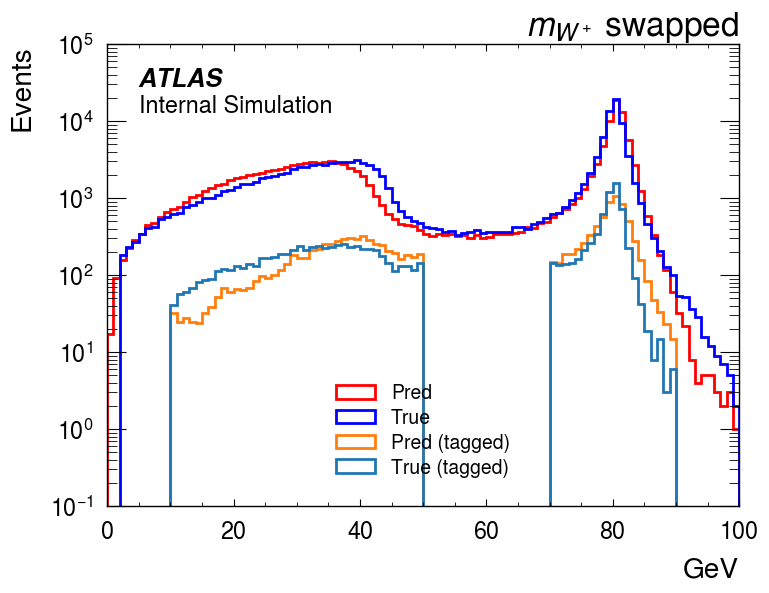

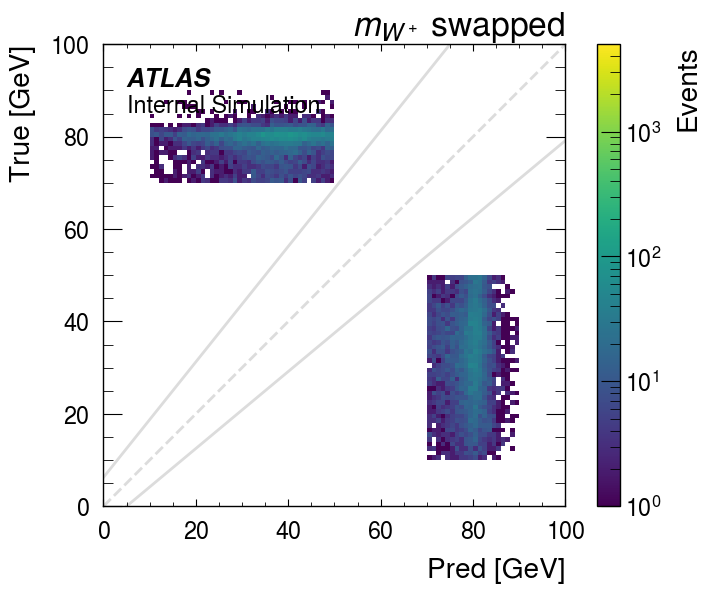

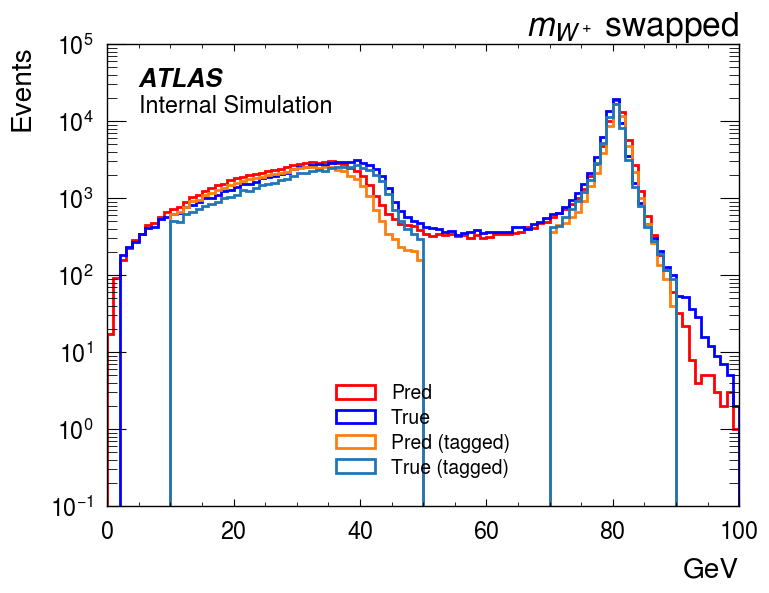

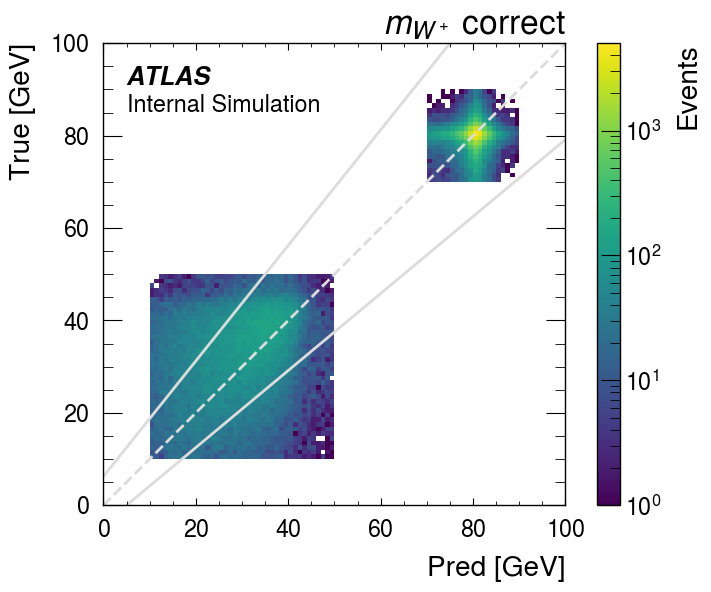

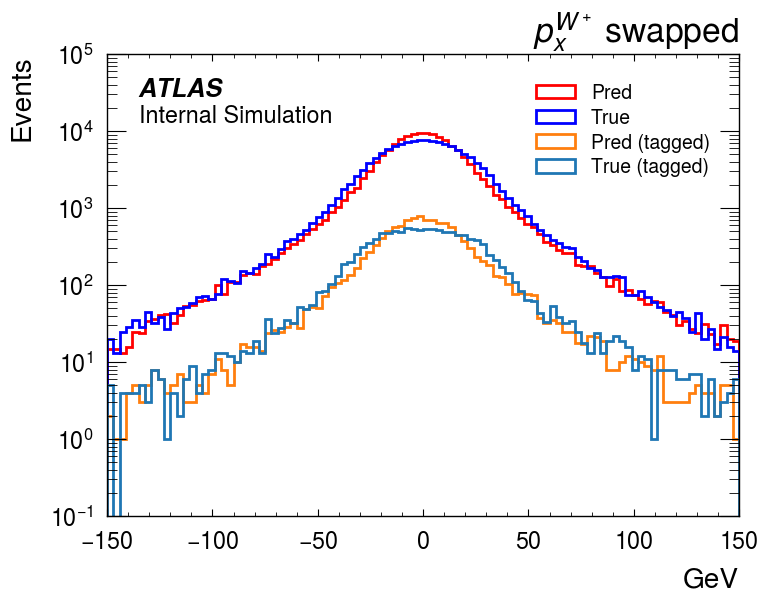

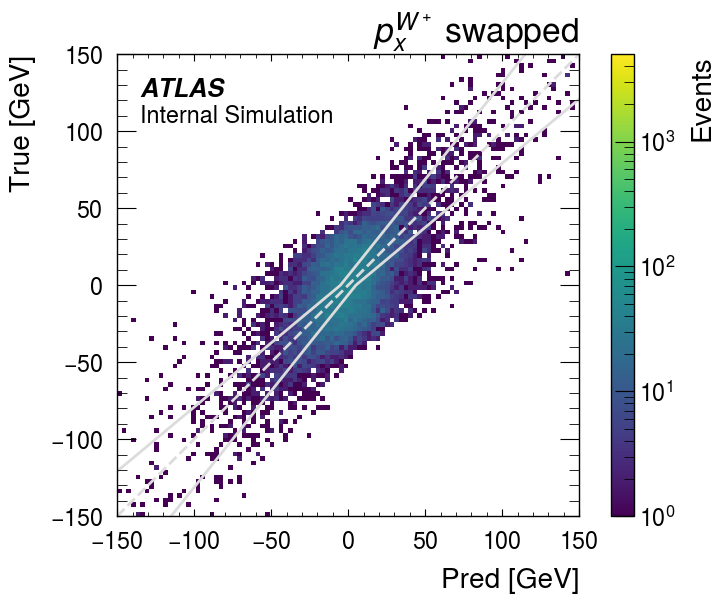

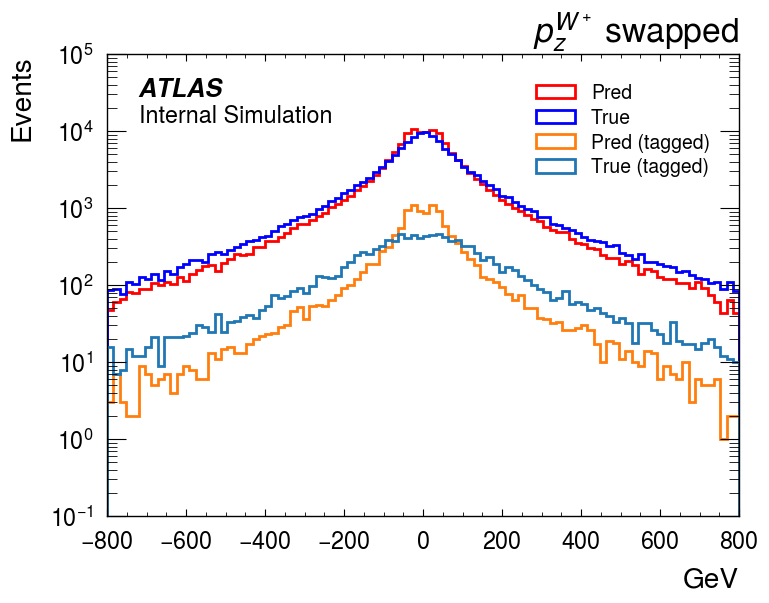

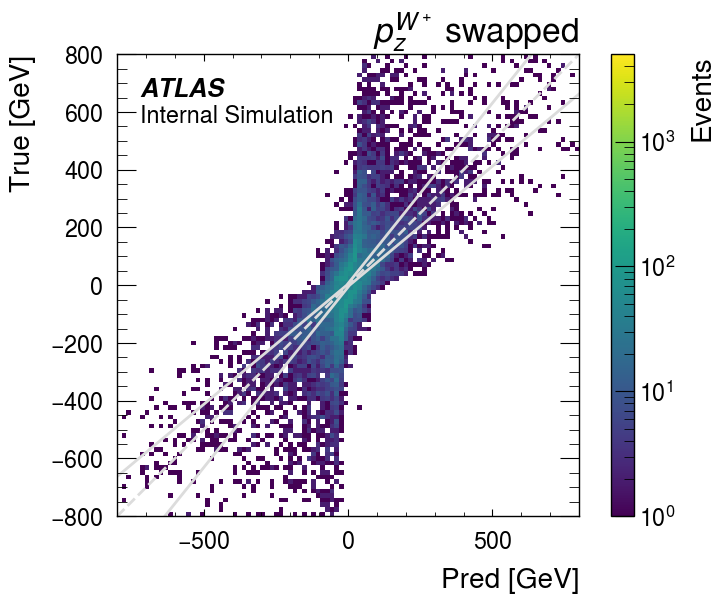

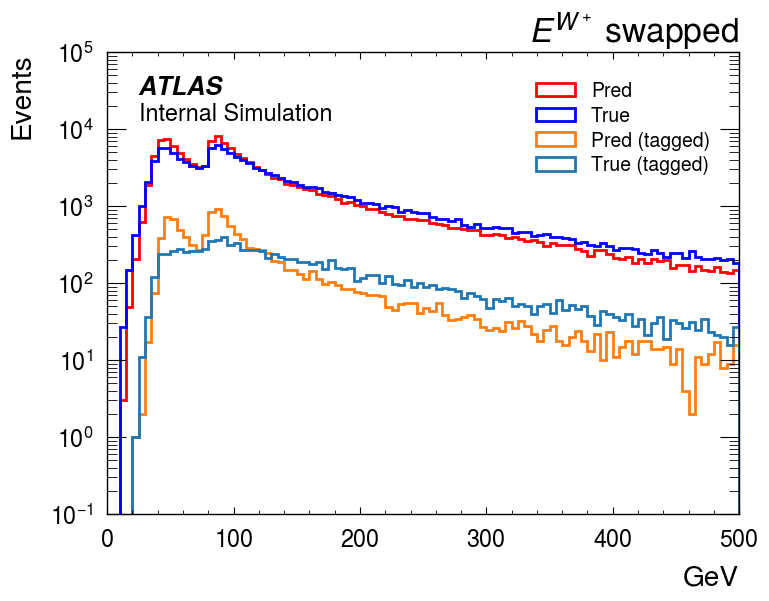

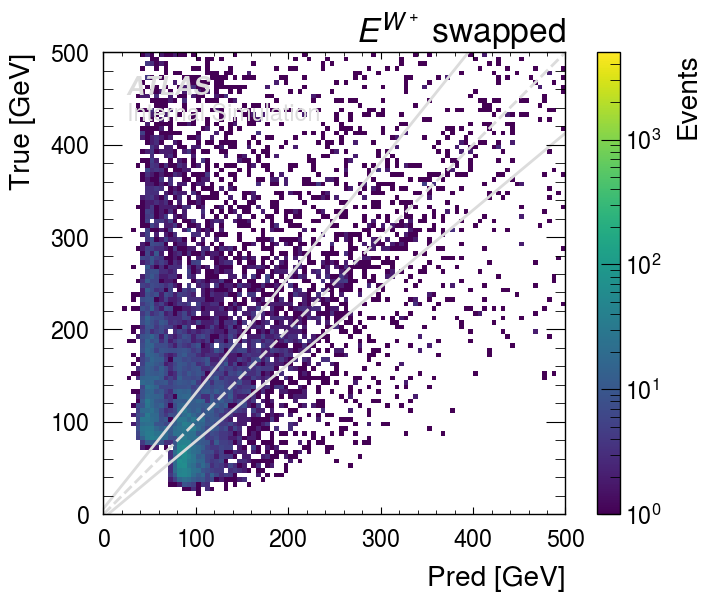

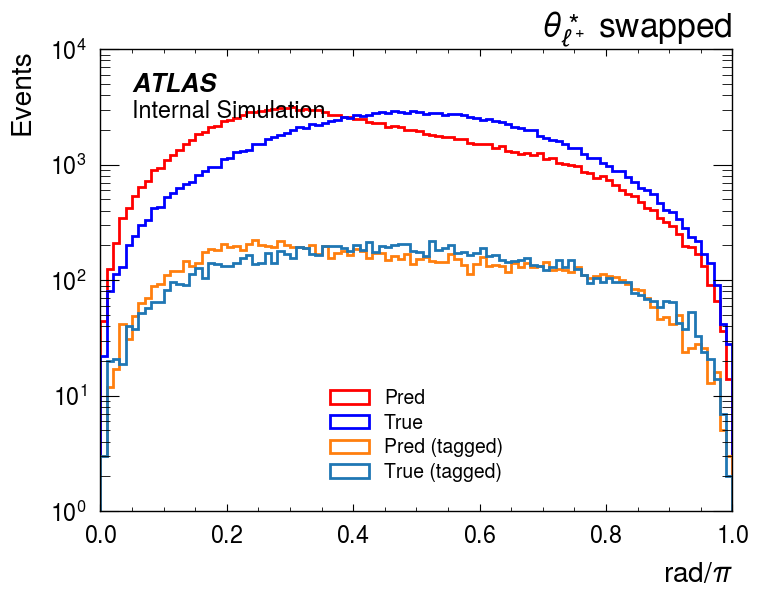

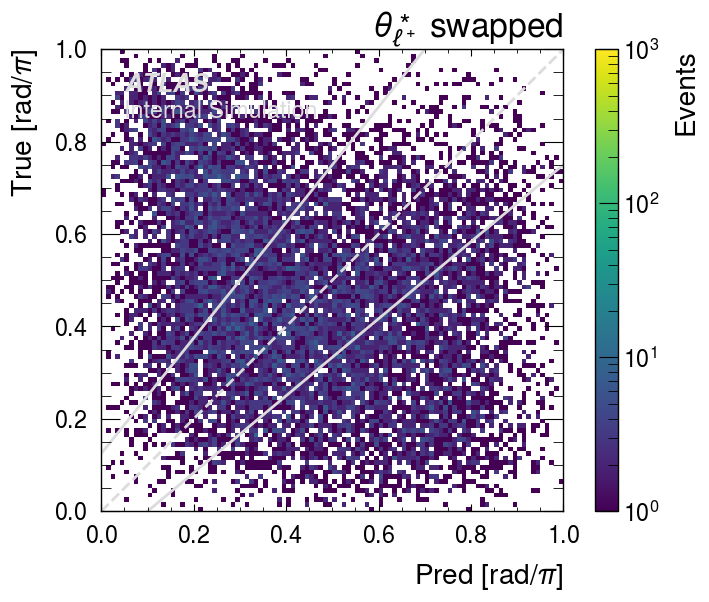

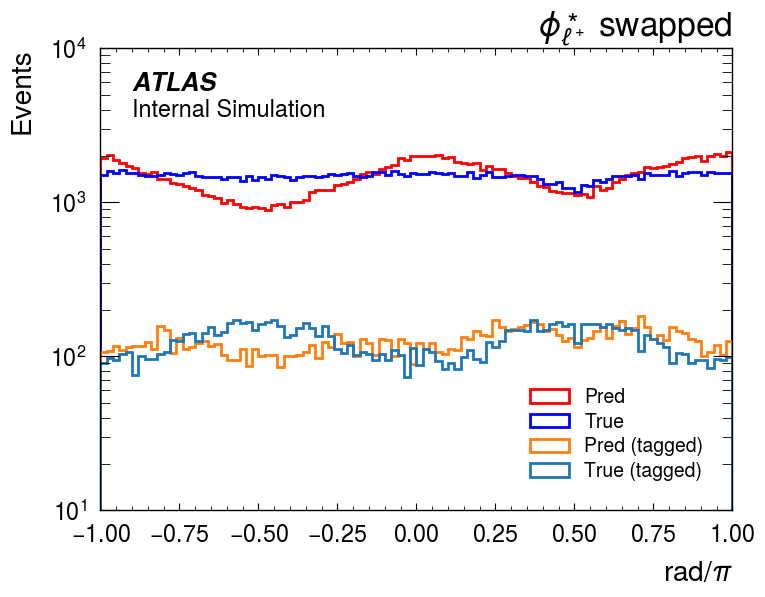

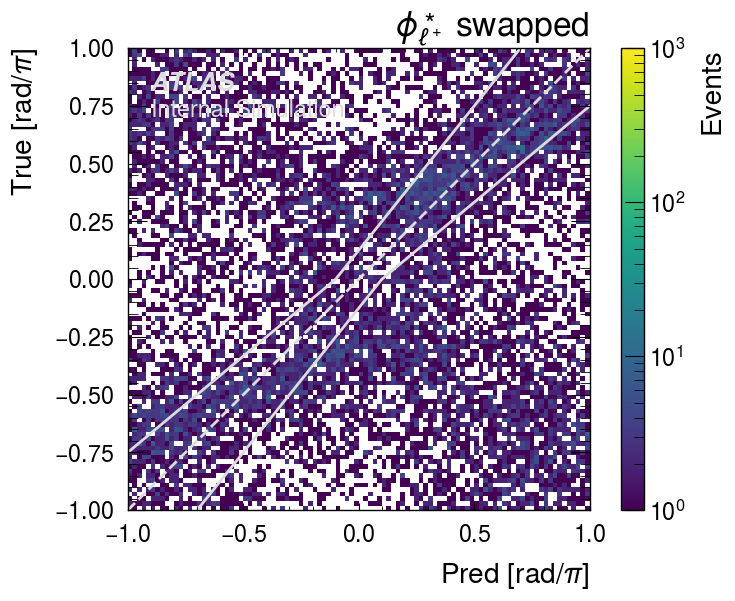

In [27]:
plot_1d_swap_hist(pred_w0_mass, true_w0_mass, pred_w0_mass[pred_swap], true_w0_mass[pred_swap], "$m_{W^+}$ swapped", np.linspace(0, 100, 101))
plot_2d_swap_hist(pred_w0_mass[pred_swap], true_w0_mass[pred_swap], "$m_{W^+}$ swapped", np.linspace(0, 100, 101), log=True)
plot_1d_swap_hist(pred_w0_mass, true_w0_mass, pred_w0_mass[pred_correct], true_w0_mass[pred_correct], "$m_{W^+}$ swapped", np.linspace(0, 100, 101))
plot_2d_swap_hist(pred_w0_mass[pred_correct], true_w0_mass[pred_correct], "$m_{W^+}$ correct", np.linspace(0, 100, 101), log=True)

plot_1d_swap_hist(pred_w0_px, true_w0_px, pred_w0_px[pred_swap], true_w0_px[pred_swap], "$p^{W^+}_x$ swapped", np.linspace(-150, 150, 101))
plot_2d_swap_hist(pred_w0_px[pred_swap], true_w0_px[pred_swap], "$p^{W^+}_x$ swapped", np.linspace(-150, 150, 101), log=True)
plot_1d_swap_hist(pred_w0_pz, true_w0_pz, pred_w0_pz[pred_swap], true_w0_pz[pred_swap], "$p^{W^+}_z$ swapped", np.linspace(-800, 800, 101))
plot_2d_swap_hist(pred_w0_pz[pred_swap], true_w0_pz[pred_swap], "$p^{W^+}_z$ swapped", np.linspace(-800, 800, 101), log=True)
plot_1d_swap_hist(pred_w0_energy, true_w0_energy, pred_w0_energy[pred_swap], true_w0_energy[pred_swap], "$E^{W^+}$ swapped", np.linspace(0, 500, 101))
plot_2d_swap_hist(pred_w0_energy[pred_swap], true_w0_energy[pred_swap], "$E^{W^+}$ swapped", np.linspace(0, 500, 101), log=True, color="gainsboro",)

plot_1d_swap_hist(pred_l0_theta_phi[0], true_l0_theta_phi[0], pred_l0_theta_phi[0][pred_swap], true_l0_theta_phi[0][pred_swap], r"$\theta^\ast_{\ell^+}$ swapped", np.linspace(0, 1, 101), unit="rad/$\pi$")
plot_2d_swap_hist(pred_l0_theta_phi[0][pred_swap], true_l0_theta_phi[0][pred_swap], r"$\theta^\ast_{\ell^+}$ swapped", np.linspace(0, 1, 101), vmax=1e3, log=True, unit="rad/$\pi$", color="gainsboro", offset=0.1)
plot_1d_swap_hist(pred_l0_theta_phi[1], true_l0_theta_phi[1], pred_l0_theta_phi[1][pred_swap], true_l0_theta_phi[1][pred_swap], r"$\phi^\ast_{\ell^+}$ swapped", np.linspace(-1, 1, 101), unit="rad/$\pi$")
plot_2d_swap_hist(pred_l0_theta_phi[1][pred_swap], true_l0_theta_phi[1][pred_swap], r"$\phi^\ast_{\ell^+}$ swapped", np.linspace(-1, 1, 101), vmax=1e3, log=True, unit="rad/$\pi$", color="gainsboro", offset=0.1)

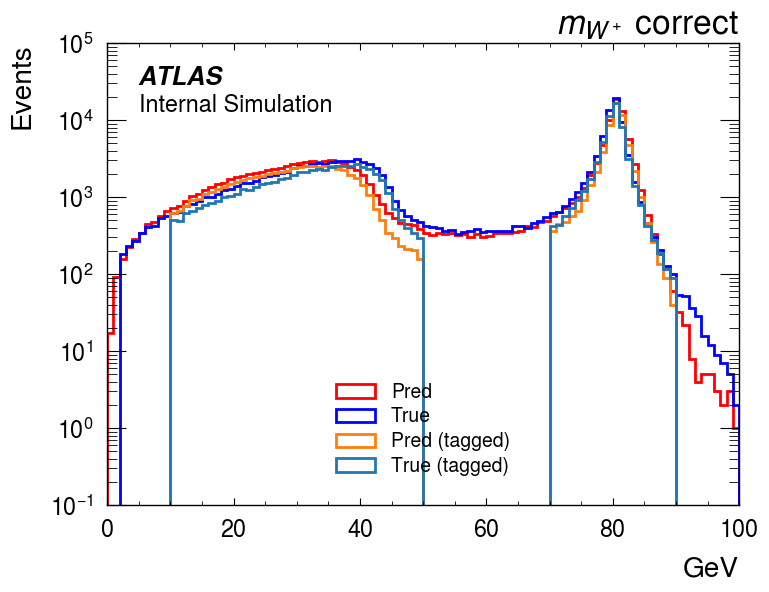

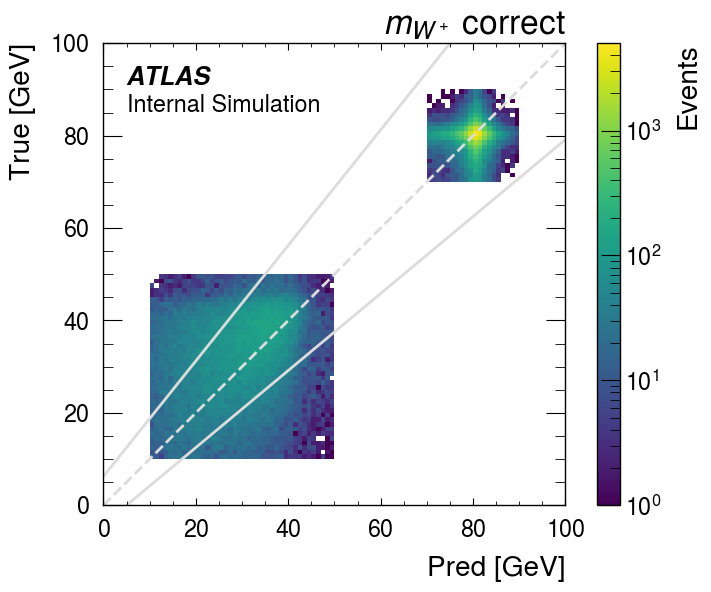

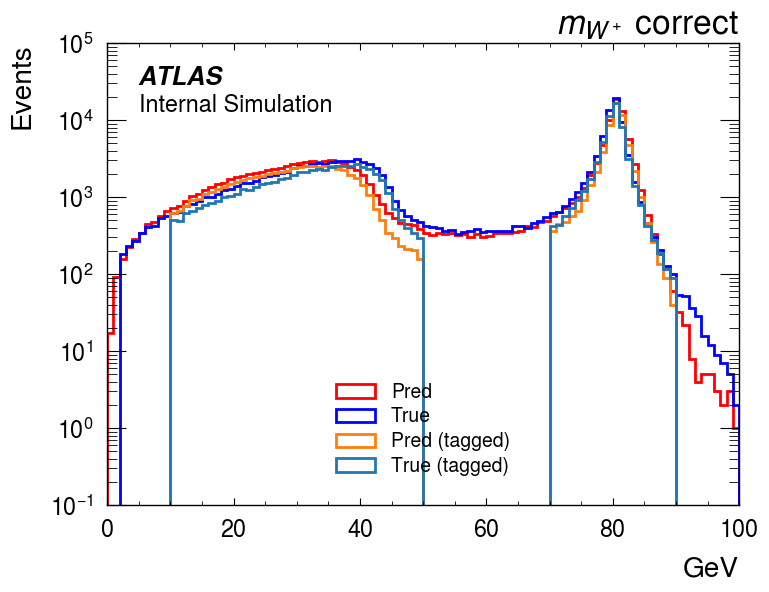

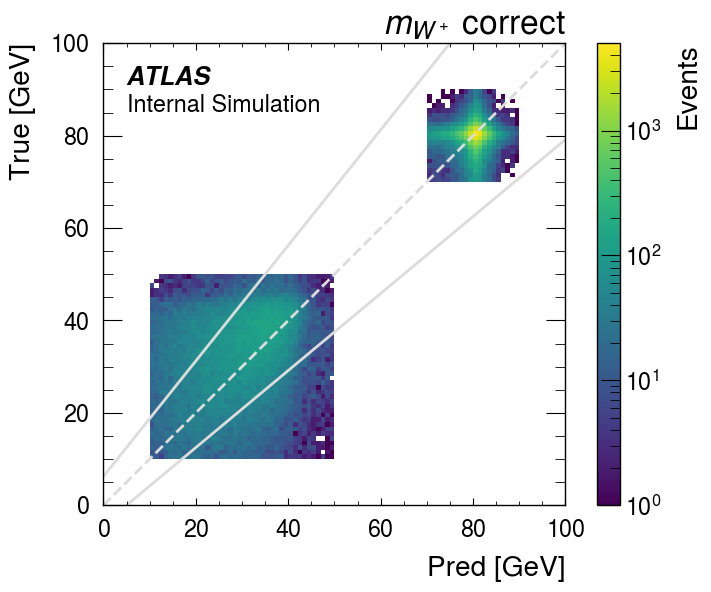

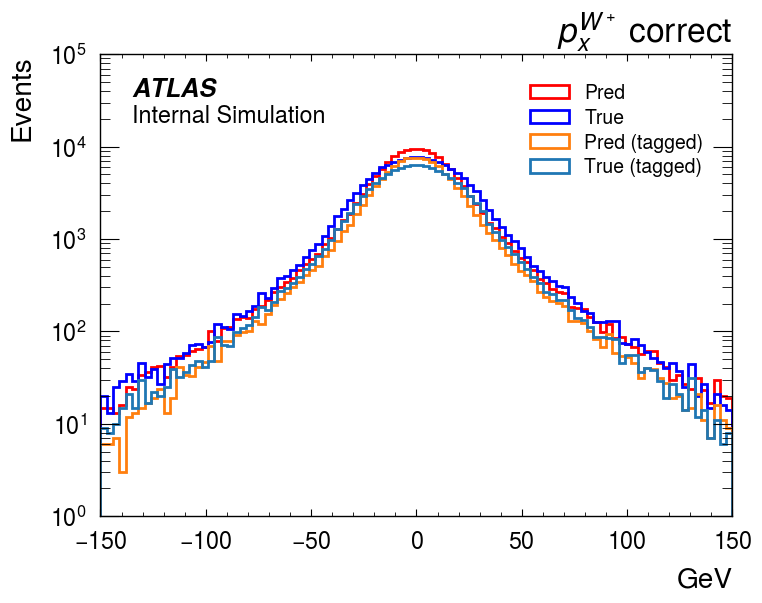

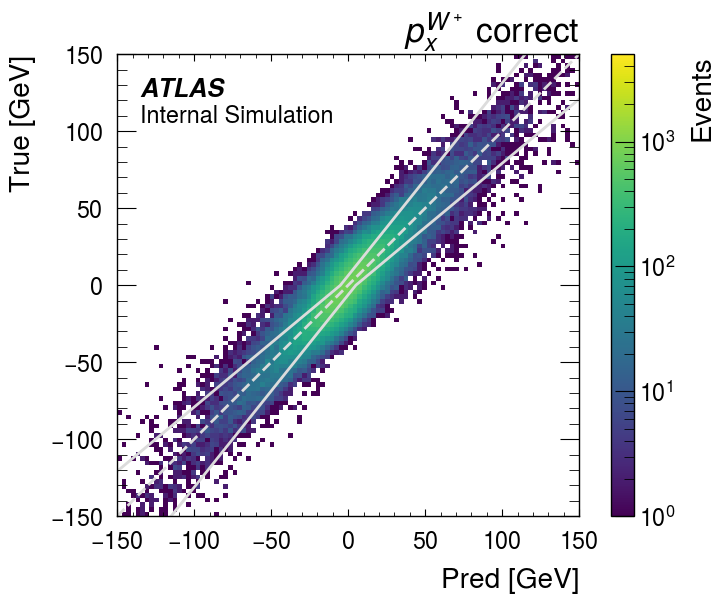

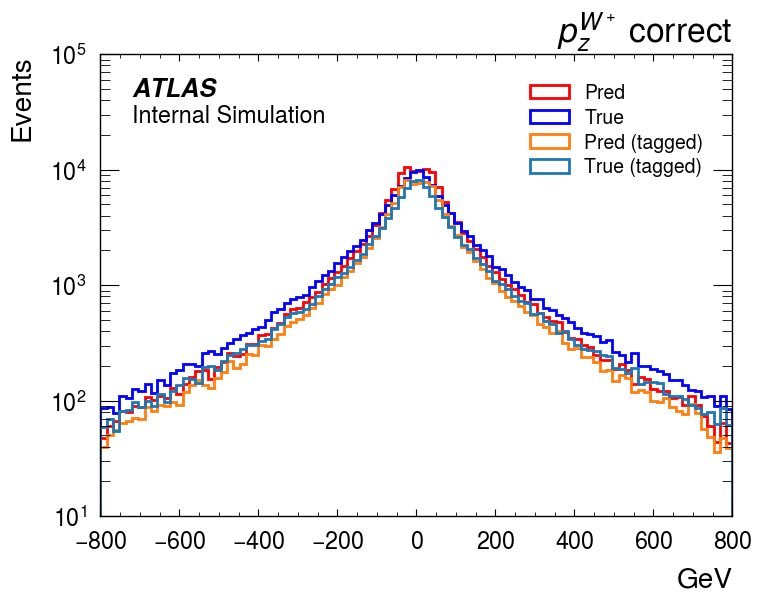

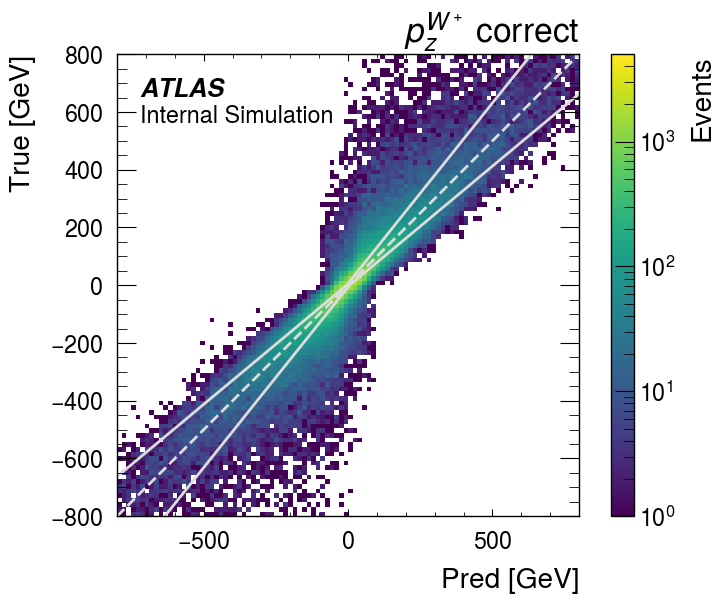

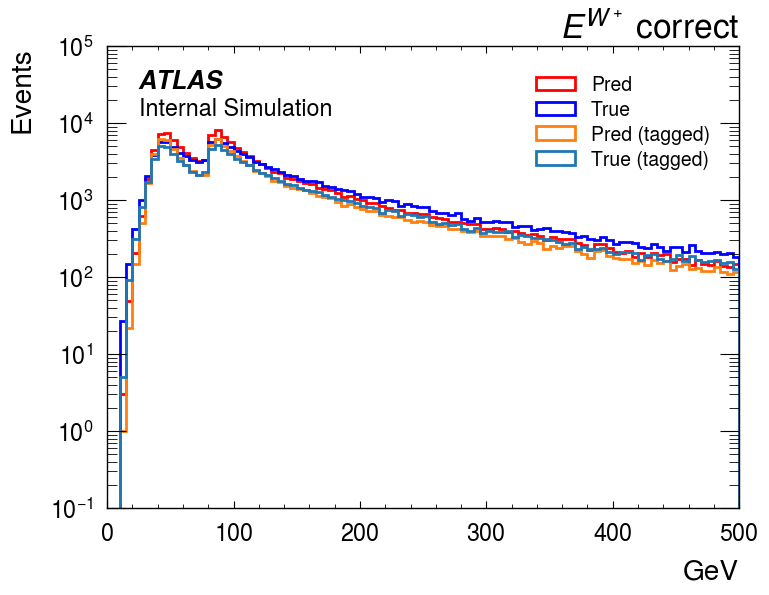

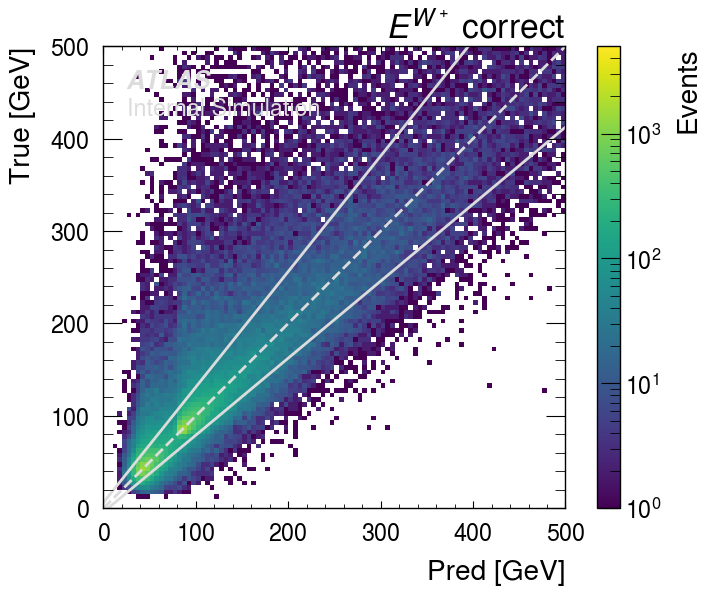

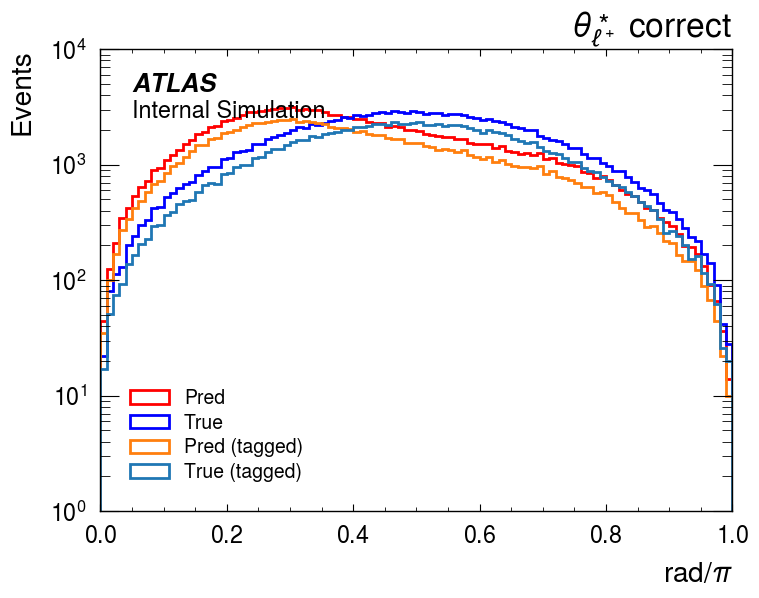

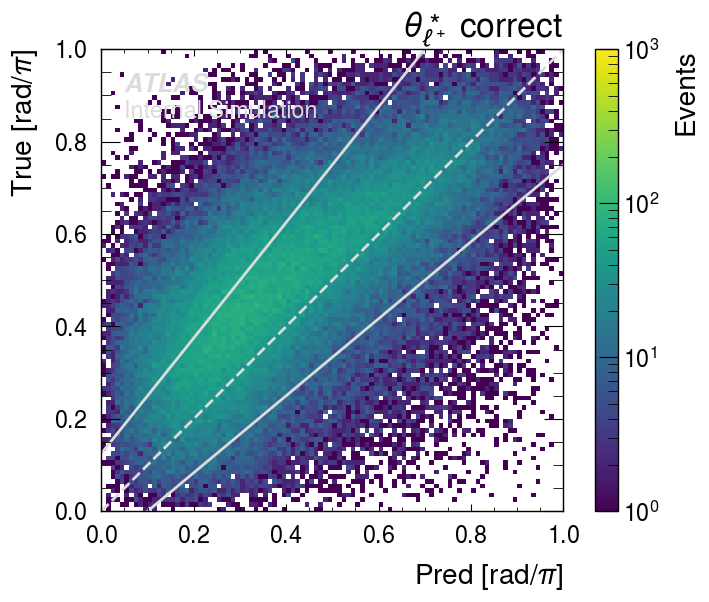

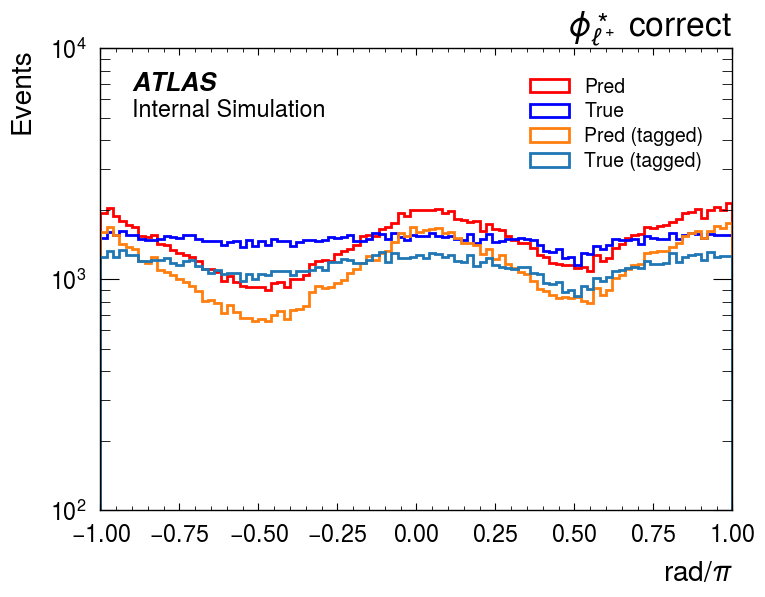

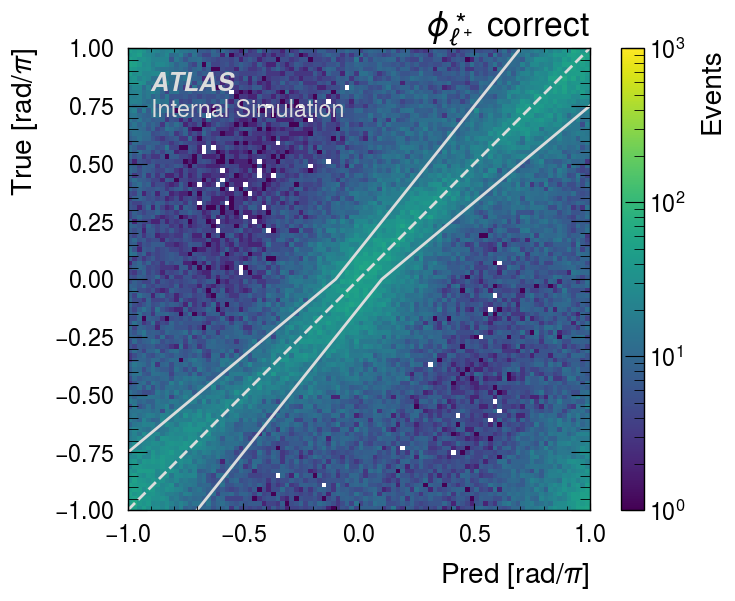

In [28]:
plot_1d_swap_hist(pred_w0_mass, true_w0_mass, pred_w0_mass[pred_correct], true_w0_mass[pred_correct], "$m_{W^+}$ correct", np.linspace(0, 100, 101))
plot_2d_swap_hist(pred_w0_mass[pred_correct], true_w0_mass[pred_correct], "$m_{W^+}$ correct", np.linspace(0, 100, 101), log=True)
plot_1d_swap_hist(pred_w0_mass, true_w0_mass, pred_w0_mass[pred_correct], true_w0_mass[pred_correct], "$m_{W^+}$ correct", np.linspace(0, 100, 101))
plot_2d_swap_hist(pred_w0_mass[pred_correct], true_w0_mass[pred_correct], "$m_{W^+}$ correct", np.linspace(0, 100, 101), log=True)

plot_1d_swap_hist(pred_w0_px, true_w0_px, pred_w0_px[pred_correct], true_w0_px[pred_correct], "$p^{W^+}_x$ correct", np.linspace(-150, 150, 101))
plot_2d_swap_hist(pred_w0_px[pred_correct], true_w0_px[pred_correct], "$p^{W^+}_x$ correct", np.linspace(-150, 150, 101), log=True)
plot_1d_swap_hist(pred_w0_pz, true_w0_pz, pred_w0_pz[pred_correct], true_w0_pz[pred_correct], "$p^{W^+}_z$ correct", np.linspace(-800, 800, 101))
plot_2d_swap_hist(pred_w0_pz[pred_correct], true_w0_pz[pred_correct], "$p^{W^+}_z$ correct", np.linspace(-800, 800, 101), log=True)
plot_1d_swap_hist(pred_w0_energy, true_w0_energy, pred_w0_energy[pred_correct], true_w0_energy[pred_correct], "$E^{W^+}$ correct", np.linspace(0, 500, 101))
plot_2d_swap_hist(pred_w0_energy[pred_correct], true_w0_energy[pred_correct], "$E^{W^+}$ correct", np.linspace(0, 500, 101), log=True, color="gainsboro",)

plot_1d_swap_hist(pred_l0_theta_phi[0], true_l0_theta_phi[0], pred_l0_theta_phi[0][pred_correct], true_l0_theta_phi[0][pred_correct], r"$\theta^\ast_{\ell^+}$ correct", np.linspace(0, 1, 101), unit="rad/$\pi$")
plot_2d_swap_hist(pred_l0_theta_phi[0][pred_correct], true_l0_theta_phi[0][pred_correct], r"$\theta^\ast_{\ell^+}$ correct", np.linspace(0, 1, 101), vmax=1e3, log=True, unit="rad/$\pi$", color="gainsboro", offset=0.1)
plot_1d_swap_hist(pred_l0_theta_phi[1], true_l0_theta_phi[1], pred_l0_theta_phi[1][pred_correct], true_l0_theta_phi[1][pred_correct], r"$\phi^\ast_{\ell^+}$ correct", np.linspace(-1, 1, 101), unit="rad/$\pi$")
plot_2d_swap_hist(pred_l0_theta_phi[1][pred_correct], true_l0_theta_phi[1][pred_correct], r"$\phi^\ast_{\ell^+}$ correct", np.linspace(-1, 1, 101), vmax=1e3, log=True, unit="rad/$\pi$", color="gainsboro", offset=0.1)

Found log directories: ['./hww_pcres_regressor/logs/version_0']


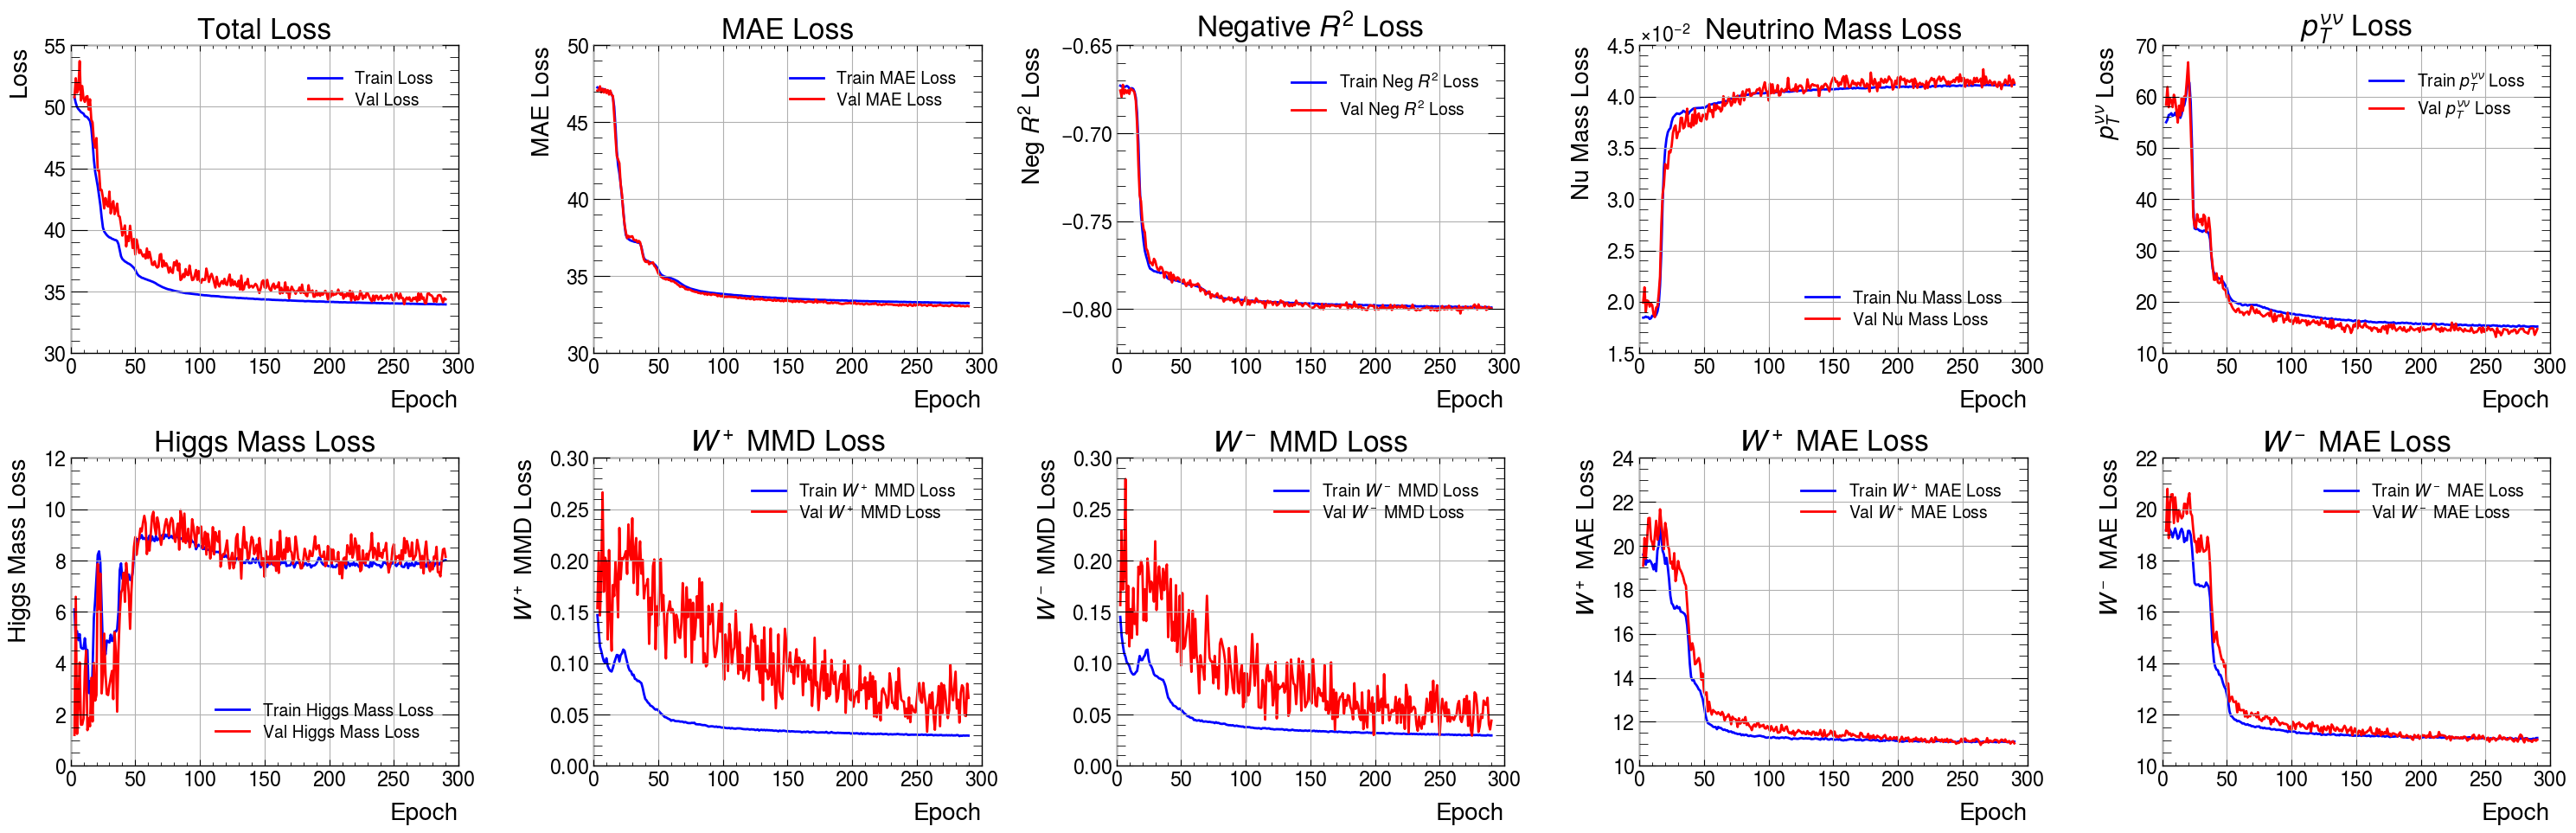


Final Training Losses (Epoch 290):
  Total Loss: 33.953327
  MAE Loss: 33.246887
  Negative $R^2$ Loss: -0.799119
  Neutrino Mass Loss: 0.041176
  $p^{\nu\nu}_T$ Loss: 15.174067
  Higgs Mass Loss: 8.011059
  $W^+$ MMD Loss: 0.029341
  $W^-$ MMD Loss: 0.029533
  $W^+$ MAE Loss: 11.094769
  $W^-$ MAE Loss: 11.082056

Final Validation Losses:
  Total Loss: 34.365051
  MAE Loss: 33.044502
  Negative $R^2$ Loss: -0.799645
  Neutrino Mass Loss: 0.041326
  $p^{\nu\nu}_T$ Loss: 14.685281
  Higgs Mass Loss: 8.143530
  $W^+$ MMD Loss: 0.066119
  $W^-$ MMD Loss: 0.043927
  $W^+$ MAE Loss: 11.020099
  $W^-$ MAE Loss: 11.015844


In [29]:
log_dirs = glob.glob("./hww_pcres_regressor/logs/*")
print(f"Found log directories: {log_dirs}")
if not log_dirs:
    print("No logs found.")
else:
    metrics_path = os.path.join(log_dirs[0], "metrics.csv")
    if not os.path.exists(metrics_path):
        print(f"No metrics.csv found in {log_dirs[0]}")
    else:
        df = pd.read_csv(metrics_path)
        df_clean = df.copy()
        df_clean_train = (
            df_clean[df_clean["loss"].notna()] if "loss" in df_clean.columns else pd.DataFrame()
        )
        df_clean_val = (
            df_clean[df_clean["val_loss"].notna()] if "val_loss" in df_clean.columns else pd.DataFrame()
        )

        if df_clean_train.empty or df_clean_val.empty:
            print("Not enough training or validation records to visualize.")
        else:
            fig, axes = plt.subplots(2, 5, figsize=(30, 10))
            axes = axes.flatten()

            plot_configs = [
                ("loss", "val_loss", "Total Loss", "Loss"),
                ("mae_loss", "val_mae_loss", "MAE Loss", "MAE Loss"),
                ("neg_r2_loss", "val_neg_r2_loss", "Negative $R^2$ Loss", "Neg $R^2$ Loss"),
                ("nu_mass_loss", "val_nu_mass_loss", "Neutrino Mass Loss", "Nu Mass Loss"),
                ("dinu_pt_loss", "val_dinu_pt_loss", r"$p^{\nu\nu}_T$ Loss", r"$p^{\nu\nu}_T$ Loss"),
                ("higgs_mass_loss", "val_higgs_mass_loss", "Higgs Mass Loss", "Higgs Mass Loss"),
                ("w_mass_mmd0_loss", "val_w_mass_mmd0_loss", "$W^+$ MMD Loss", "$W^+$ MMD Loss"),
                ("w_mass_mmd1_loss", "val_w_mass_mmd1_loss", "$W^-$ MMD Loss", "$W^-$ MMD Loss"),
                ("w0_mass_mae_loss", "val_w0_mass_mae_loss", "$W^+$ MAE Loss", "$W^+$ MAE Loss"),
                ("w1_mass_mae_loss", "val_w1_mass_mae_loss", "$W^-$ MAE Loss", "$W^-$ MAE Loss"),
            ]

            def apply_scale(ax, data):
                finite = data.replace([np.inf, -np.inf], np.nan).dropna()
                if finite.empty:
                    return
                if (finite <= 0).any():
                    ax.set_yscale("symlog", linthresh=1e-3)
                else:
                    ax.set_yscale("log")

            epochs_train = df_clean_train["epoch"].iloc[3:]
            epochs_val = df_clean_val["epoch"].iloc[3:]

            for ax, (train_col, val_col, title, ylabel) in zip(axes, plot_configs):
                if train_col not in df_clean_train.columns or val_col not in df_clean_val.columns:
                    ax.set_visible(False)
                    continue

                ax.plot(epochs_train, df_clean_train[train_col].iloc[3:], label=f"Train {ylabel}", color="blue")
                ax.plot(epochs_val, df_clean_val[val_col].iloc[3:], label=f"Val {ylabel}", color="red")
                ax.set_xlabel("Epoch")
                ax.set_ylabel(ylabel)
                ax.set_title(title)
                ax.legend()
                ax.grid(True)
                # apply_scale(ax, pd.concat([df_clean_train[train_col], df_clean_val[val_col]]))

            plt.tight_layout()
            plt.show()

            last_epoch = df_clean_train["epoch"].iloc[-1]
            print(f"\nFinal Training Losses (Epoch {last_epoch}):")
            for train_col, _, title, _ in plot_configs:
                if train_col in df_clean_train.columns:
                    print(f"  {title}: {df_clean_train[train_col].iloc[-1]:.6f}")

            print("\nFinal Validation Losses:")
            for _, val_col, title, _ in plot_configs:
                if val_col in df_clean_val.columns:
                    print(f"  {title}: {df_clean_val[val_col].iloc[-1]:.6f}")